## Importing Packages ##

In [ ]:
import numpy as np         
import pandas as pd                                                     
import matplotlib.pyplot as plt                              ## General Packages
import glob
from scipy.optimize import curve_fit
from scipy.spatial import cKDTree
from warnings import filterwarnings
filterwarnings('ignore')

import ccdproc                           ## CCD Processing package
import astroalign                        ## Used for alligning frames

import astropy                           ## Astropy related packages
from astropy.table import vstack
from astropy.nddata import CCDData
from astropy.stats import SigmaClip                           
from astropy.convolution import convolve

from photutils.background import Background2D, MedianBackground                      ## Photutils related packages
from photutils.segmentation import make_2dgaussian_kernel, detect_sources, deblend_sources, SourceCatalog
from photutils.utils import calc_total_error
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats

## Master Frames ##

### V-Band Data ###

In [ ]:
BiasFrames_V = glob.glob('NGC_6341 Data/V-band/Bias/*.fit')   ## converting all bias frames into a list so that the ccdproc package can combine them all

for f in BiasFrames_V:
    bias = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    biasarray = np.array(bias)
    print(f'The mean of {f} bias frame is {np.mean(biasarray)} and it has a standard deviation of {np.std(biasarray)} ADU')
    
MasterBiasFrame_V = ccdproc.combine(BiasFrames_V, method = 'median', unit = 'adu') ##median combining all the frames

hdul = astropy.nddata.CCDData.to_hdu(MasterBiasFrame_V)       ## creating the master frame 
hdul.writeto('NGC_6341 Data/V-band/Master Frames/MasterBiasFrame_V.bias.fit', overwrite = True)

M_Bias_V = astropy.nddata.CCDData.read('NGC_6341 Data/V-band/Master Frames/MasterBiasFrame_V.bias.fit', unit = 'adu') ## reading and calculating the mean + std of the master bias frame
MBiasarray_V = np.array(M_Bias_V)

print( f'The mean of the Master Bias Frame is {np.mean(MBiasarray_V)} and it has a standard deviation of {np.std(MBiasarray_V)} ADU') 

Set OBSGEO-Y to  -131185.767 from OBSGEO-[LBH].
Set OBSGEO-Z to  5055549.706 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000836.fit bias frame is 946.0469833612442 and it has a standard deviation of 9.028935315211628 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000837.fit bias frame is 946.5977226495743 and it has a standard deviation of 8.927958131097554 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000838.fit bias frame is 946.6919199228287 and it has a standard deviation of 8.87959417956627 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000839.fit bias frame is 946.9821738004684 and it has a standard deviation of 8.890071391239047 ADU


...

The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000851.fit bias frame is 947.7234557271004 and it has a standard deviation of 8.978523167426006 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000852.fit bias frame is 947.9758606553078 and it has a standard deviation of 8.917443408380858 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000853.fit bias frame is 947.9807251691818 and it has a standard deviation of 8.868793483086241 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000854.fit bias frame is 947.6274157166481 and it has a standard deviation of 8.916043073541807 ADU


The mean of NGC_6341 Data/V-band/Bias\Bias_Sky Chart Center_0.000secs_V_00000855.fit bias frame is 947.8759583830833 and it has a standard deviation of 8.841510823997028 ADU
INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
The mean of the Master Bias Frame is 947.3415930271149 and it has a standard deviation of 5.385537224410212 ADU


In [ ]:
DarkFrames_V = glob.glob('NGC_6341 Data/V-band/Dark/*.fit')  ##Note: t_exp for dark is 30 seconds

for f in DarkFrames_V:
    dark = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    darkarray = np.array(dark)
    print(f'The mean of {f} dark frame is {np.mean(darkarray)} and it has a standard deviation of {np.std(darkarray)} ADU')

Reduced_DarkFrames_V = [(astropy.nddata.CCDData.read(f, unit='adu')).subtract(MasterBiasFrame_V) for f in DarkFrames_V] ##subtracting master bias from all frames
MasterDarkFrame_V =  ccdproc.combine(Reduced_DarkFrames_V, method = 'median')  

hdul = astropy.nddata.CCDData.to_hdu(MasterDarkFrame_V)                                                   ## Create the master dark frame 
hdul.writeto('NGC_6341 Data/V-band/Master Frames/MasterDarkFrame_V.dark.fit', overwrite =True)

M_Dark_V = astropy.nddata.CCDData.read('NGC_6341 Data/V-band/Master Frames/MasterDarkFrame_V.dark.fit', unit ='adu')
MDarkarray_V = np.array(M_Dark_V)

print( f'The mean of the Dark Frame is {np.mean(MDarkarray_V)} and it has a standard deviation of {np.std(MDarkarray_V)} ADU')  ## calculating the mean + std of the master dark frame

The mean of NGC_6341 Data/V-band/Dark\Dark_Sky Chart Center_30.000secs_V_00000856.fit dark frame is 947.8364559412003 and it has a standard deviation of 52.796560888562276 ADU


The mean of NGC_6341 Data/V-band/Dark\Dark_Sky Chart Center_30.000secs_V_00000857.fit dark frame is 947.5682935118675 and it has a standard deviation of 52.7808996423832 ADU


The mean of NGC_6341 Data/V-band/Dark\Dark_Sky Chart Center_30.000secs_V_00000858.fit dark frame is 947.4210016131401 and it has a standard deviation of 52.71903563552146 ADU


The mean of NGC_6341 Data/V-band/Dark\Dark_Sky Chart Center_30.000secs_V_00000859.fit dark frame is 947.1371782422066 and it has a standard deviation of 52.793768555994816 ADU


The mean of NGC_6341 Data/V-band/Dark\Dark_Sky Chart Center_30.000secs_V_00000860.fit dark frame is 947.2139269709587 and it has a standard deviation of 52.80765754570332 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
The mean of the Dark Frame is 0.04906809329986572 and it has a standard deviation of 50.03594843288923 ADU


In [ ]:
dark_current_V = np.mean(MDarkarray_V) / 30 * 1.38                  ### calculating the dark current given the gain of the device
print(f'The dark current is {dark_current_V} e-/pixel/sec')

The dark current is 0.002257132291793823 e-/pixel/sec


In [ ]:
FlatFrames_V = glob.glob('NGC_6341 Data/V-band/Flats/*.fit')


for f in FlatFrames_V:
    flats = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    flatarray = np.array(flats)
    print(f'The mean of {f} flat frame is {np.mean(flatarray)} and it has a standard deviation of {np.std(flatarray)} ADU')

N_FlatFramesV = []

for f in FlatFrames_V:
    flat = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = flat.header['EXPTIME']
    scaled_dark = MasterDarkFrame_V.multiply(exptime / 30)                  ## Scaling the Master Dark Frame to the exposure time of the flat frame
    BiasR_FlatFrameV = flat.subtract(MasterBiasFrame_V)                     ## Subtracting Master Bias from all Flat Frames]
    Reduced_FlatFrameV = BiasR_FlatFrameV.subtract(scaled_dark)
    Norm_FlatFrame_V = Reduced_FlatFrameV.divide(np.mean(np.array(Reduced_FlatFrameV)))         ## Normalising the Flat Frame
    Normalised_FlatFramesV = N_FlatFramesV.append(Norm_FlatFrame_V)

MasterFlatVFrame = ccdproc.combine(N_FlatFramesV, method = 'median')
hdul = astropy.nddata.CCDData.to_hdu(MasterFlatVFrame)                                            ## Creating the median combined Master Flat Frame 
hdul.writeto('NGC_6341 Data/V-band/Master Frames/MasterFlatFrame_V.flat.fits', overwrite =True)

The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001171.fit flat frame is 3052.5137697458267 and it has a standard deviation of 96.10734282675028 ADU
The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001172.fit flat frame is 3057.5796115398407 and it has a standard deviation of 97.04511213507213 ADU


The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001173.fit flat frame is 3062.161643445492 and it has a standard deviation of 97.8711325902566 ADU
The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001174.fit flat frame is 3066.96487224102 and it has a standard deviation of 97.94807989782959 ADU


The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001175.fit flat frame is 3068.97338193655 and it has a standard deviation of 97.32024653513905 ADU
The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001176.fit flat frame is 3071.927493751049 and it has a standard deviation of 96.83116436930206 ADU


The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001177.fit flat frame is 3074.617074906826 and it has a standard deviation of 98.01753639661081 ADU
The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001178.fit flat frame is 3077.282110631466 and it has a standard deviation of 97.94170375991818 ADU


The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001179.fit flat frame is 3077.921043932438 and it has a standard deviation of 97.98350519309726 ADU
The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001180.fit flat frame is 3079.7432028651237 and it has a standard deviation of 98.2816985125762 ADU


The mean of NGC_6341 Data/V-band/Flats\FlatField_NGC6781_5.000secs_V_00001181.fit flat frame is 3080.8928980231285 and it has a standard deviation of 99.10779870029293 ADU


In [ ]:
ScienceFrames_V = glob.glob('NGC_6341 Data/V-band/Science_V/*.fit')

for f in ScienceFrames_V:
    science = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    sciencearray = np.array(science)
    print(f'The mean of {f} science frame is {np.mean(sciencearray)} and it has a standard deviation of {np.std(sciencearray)} ADU')

## Need to remove 64,82,83,84 for clouds and 68 for cosmic ray
i = 100

ScienceFrames_V = glob.glob('NGC_6341 Data/V-band/Science_V/*.fit')
for f in ScienceFrames_V:
    science = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = science.header['EXPTIME']
    scaled_dark = MasterDarkFrame_V.multiply(exptime / 30)                   ## Scaling the Master Dark Frame to the exposure time of the science frame
    BR_ScienceFrameV = science.subtract(MasterBiasFrame_V)                   ## Subtracting Master Bias from all Science Frames
    BDR_ScienceFrameV = BR_ScienceFrameV.subtract(scaled_dark)               ## Subtracting Scaled Master Dark from all Science Frames
    BDFR_ScienceFrameV = BDR_ScienceFrameV.divide(MasterFlatVFrame)          ## Dividing by Master Flat Frame to get the final reduced Science Frame

    hdul = astropy.nddata.CCDData.to_hdu(BDFR_ScienceFrameV)
    hdul.writeto(f'NGC_6341 Data/V-band/Reduced Science/V-Band Fit {i}.fit', overwrite =True)

    i += 1   

### B Band ###

#### Long Way ####

In [ ]:
BiasFrames_B = glob.glob('NGC_6341 Data/B-band/Bias/*.fit')   ## converting all bias frames into a list so that the ccdproc package can combine them all

for f in BiasFrames_B:
    bias = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    biasarray = np.array(bias)
    print(f'The mean of {f} bias frame is {np.mean(biasarray)} and it has a standard deviation of {np.std(biasarray)} ADU')
    
MasterBiasFrame_B = ccdproc.combine(BiasFrames_B, method = 'median', unit = 'adu') ##median combining all the frames

hdul = astropy.nddata.CCDData.to_hdu(MasterBiasFrame_B)       ## creating the master frame 
hdul.writeto('NGC_6341 Data/B-band/Master Frames/MasterBiasFrame_B.bias.fit', overwrite = True)

M_Bias_B = astropy.nddata.CCDData.read('NGC_6341 Data/B-band/Master Frames/MasterBiasFrame_B.bias.fit', unit = 'adu') 
MBiasarray_B = np.array(M_Bias_B)

print( f'The mean of the Master Bias Frame is {np.mean(MBiasarray_B)} and it has a standard deviation of {np.std(MBiasarray_B)} ADU') ## reading and calculating the mean + std of the master bias frame

The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001193.fit bias frame is 940.4112721681595 and it has a standard deviation of 8.947131932950592 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001194.fit bias frame is 940.4299041628838 and it has a standard deviation of 8.851890424508477 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001195.fit bias frame is 940.6857349872589 and it has a standard deviation of 8.935613560610452 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001196.fit bias frame is 940.9931204915047 and it has a standard deviation of 8.933273059388128 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001197.fit bias frame is 941.0978127121925 and it has a standard deviation of 8.907607587087657 ADU


...

The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001208.fit bias frame is 941.7632842063904 and it has a standard deviation of 8.944142265309335 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001209.fit bias frame is 941.7532109618187 and it has a standard deviation of 8.916626508903372 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001210.fit bias frame is 941.8729193806648 and it has a standard deviation of 9.012273762669615 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001211.fit bias frame is 941.8095169663429 and it has a standard deviation of 8.9009611524361 ADU


The mean of NGC_6341 Data/B-band/Bias\Bias_NoTarget_0.000secs_B_00001212.fit bias frame is 941.8128457069397 and it has a standard deviation of 8.91333629714163 ADU
INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
The mean of the Master Bias Frame is 941.4062569439411 and it has a standard deviation of 5.338381600398732 ADU


In [ ]:
DarkFrames_B = glob.glob('NGC_6341 Data/B-band/Dark/*.fit')  

for f in DarkFrames_B:
    dark = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    darkarray = np.array(dark)
    print(f'The mean of {f} dark frame is {np.mean(darkarray)} and it has a standard deviation of {np.std(darkarray)} ADU')

Reduced_DarkFrames_B = [(astropy.nddata.CCDData.read(f, unit='adu')).subtract(MasterBiasFrame_B) for f in DarkFrames_B]
MasterDarkFrame_B =  ccdproc.combine(Reduced_DarkFrames_B, method = 'median')  

hdul = astropy.nddata.CCDData.to_hdu(MasterDarkFrame_B)                                 ## Create the master dark frame 
hdul.writeto('NGC_6341 Data/B-band/Master Frames/MasterDarkFrame_B.dark.fit', overwrite =True)

M_Dark_B = astropy.nddata.CCDData.read('NGC_6341 Data/B-band/Master Frames/MasterDarkFrame_B.dark.fit', unit ='adu')
MDarkarray_B = np.array(M_Dark_B)

print( f'The mean of the Dark Current is {np.mean(MDarkarray_B)} and it has a standard deviation of {np.std(MDarkarray_B)} ADU')  ## calculating the mean + std of the master dark frame

Set OBSGEO-Y to  -131185.767 from OBSGEO-[LBH].
Set OBSGEO-Z to  5055549.706 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


The mean of NGC_6341 Data/B-band/Dark\Dark_NoTarget_30.000secs_B_00001213.fit dark frame is 942.3140964508057 and it has a standard deviation of 52.11344098222732 ADU


The mean of NGC_6341 Data/B-band/Dark\Dark_NoTarget_30.000secs_B_00001214.fit dark frame is 942.3742744922638 and it has a standard deviation of 51.97226971675371 ADU


The mean of NGC_6341 Data/B-band/Dark\Dark_NoTarget_30.000secs_B_00001215.fit dark frame is 942.0591743588448 and it has a standard deviation of 51.970611858805036 ADU


The mean of NGC_6341 Data/B-band/Dark\Dark_NoTarget_30.000secs_B_00001216.fit dark frame is 942.1071090698242 and it has a standard deviation of 52.30264996176414 ADU


The mean of NGC_6341 Data/B-band/Dark\Dark_NoTarget_30.000secs_B_00001217.fit dark frame is 941.8502681851387 and it has a standard deviation of 52.81319480317814 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
The mean of the Dark Current is 0.6880713999271393 and it has a standard deviation of 49.42187036901689 ADU


In [ ]:
dark_current = np.mean(MDarkarray_B) / 30 * 1.27
print(f'The dark current is {dark_current} e-/pixel/sec')  ### calculating the dark current in e-/pixel/sec

The dark current is 0.029128355930248897 e-/pixel/sec


In [ ]:
FlatFrames_B = glob.glob('NGC_6341 Data/B-band/Flat/*.fit')

for f in FlatFrames_B:
    flats = astropy.nddata.CCDData.read(f, unit = 'adu')    ## checking for outliers within the data
    flatarray = np.array(flats)
    print(f'The mean of {f} flat frame is {np.mean(flatarray)} and it has a standard deviation of {np.std(flatarray)} ADU')

N_FlatFramesB = []

for f in FlatFrames_B:
    flat = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = flat.header['EXPTIME']
    scaled_dark = M_Dark_B.multiply(exptime / 30)                   ## Scaling the Master Dark Frame to the exposure time of the flat frame
    BiasR_FlatFrameB = flat.subtract(MasterBiasFrame_B)              ## Subtracting Master Bias from all Flat Frames]
    Reduced_FlatFrameB = BiasR_FlatFrameB.subtract(scaled_dark)        ## Subtracting Scaled Master Dark from all Flat Frames
    Norm_FlatFrame_B = Reduced_FlatFrameB.divide(np.mean(np.array(Reduced_FlatFrameB)))     ## Normalising the Flat Frame
    Normalised_FlatFramesB = N_FlatFramesB.append(Norm_FlatFrame_B)

MasterFlatBFrame = ccdproc.combine(N_FlatFramesB, method = 'average')
hdul = astropy.nddata.CCDData.to_hdu(MasterFlatBFrame)                                            ## Creating the median combined Master Flat Frame 
hdul.writeto('NGC_6341 Data/B-band/Master Frames/MasterFlatFrame_B.flat.fit', overwrite =True)


The mean of NGC_6341 Data/B-band/Flat\FlatField_NoTarget_10.000secs_B_00001188.fit flat frame is 5604.104088485241 and it has a standard deviation of 118.1844333318694 ADU
The mean of NGC_6341 Data/B-band/Flat\FlatField_NoTarget_10.000secs_B_00001189.fit flat frame is 5317.754335284233 and it has a standard deviation of 113.062618384628 ADU


The mean of NGC_6341 Data/B-band/Flat\FlatField_NoTarget_10.000secs_B_00001190.fit flat frame is 5043.771027207375 and it has a standard deviation of 107.04600915071826 ADU
The mean of NGC_6341 Data/B-band/Flat\FlatField_NoTarget_10.000secs_B_00001191.fit flat frame is 4791.3698390722275 and it has a standard deviation of 101.85944204907133 ADU


The mean of NGC_6341 Data/B-band/Flat\FlatField_NoTarget_10.000secs_B_00001192.fit flat frame is 4554.715450704098 and it has a standard deviation of 97.02555240246537 ADU


In [ ]:
i = 100

for f in ScienceFrames_B:
    science = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = science.header['EXPTIME']
    scaled_dark = M_Dark_B.multiply(exptime / 30)          ## Scaling the Master Dark Frame to the exposure time of the science frame
    BR_ScienceFrameB = science.subtract(MasterBiasFrame_B)     ## Subtracting Master Bias from all Science Frames
    BDR_ScienceFrameB = BR_ScienceFrameB.subtract(scaled_dark)      ## Subtracting Scaled Master Dark from all Science Frames
    BDFR_ScienceFrameB = BDR_ScienceFrameB.divide(MasterFlatBFrame)   ## Dividing by Master Flat Frame to get the final reduced Science Frame

    hdul = astropy.nddata.CCDData.to_hdu(BDFR_ScienceFrameB)
    hdul.writeto(f'NGC_6341 Data/B-band/Reduced Science/B-Band Fit {i}.fits', overwrite =True)

    i += 1   

#### Short Way ####

In [ ]:
## Combined method for running the previous cells, same method no need for checks after intial anaylsis

BiasFrames_B = glob.glob('NGC_6341 Data/B-band/Bias/*.fit')
DarkFrames_B = glob.glob('NGC_6341 Data/B-band/Dark/*.fit')
FlatFrames_B = glob.glob('NGC_6341 Data/B-band/Flat/*.fit')
ScienceFrames_B = glob.glob('NGC_6341 Data/B-band/Science_B/*.fit')

MasterBiasFrame_B = ccdproc.combine(BiasFrames_B, method = 'median', unit = 'adu')

Reduced_DarkFrames_B = [(astropy.nddata.CCDData.read(f, unit='adu')).subtract(MasterBiasFrame_B) for f in DarkFrames_B]
MasterDarkFrame_B =  ccdproc.combine(Reduced_DarkFrames_B, method = 'median') 

N_FlatFramesB = []

for f in FlatFrames_B:
    flat = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = flat.header['EXPTIME']
    scaled_dark = MasterDarkFrame_B.multiply(exptime / 30)
    BiasR_FlatFrameB = flat.subtract(MasterBiasFrame_B)
    Reduced_FlatFrameB = BiasR_FlatFrameB.subtract(scaled_dark)
    Norm_FlatFrame_B = Reduced_FlatFrameB.divide(np.mean(np.array(Reduced_FlatFrameB)))
    Normalised_FlatFramesB = N_FlatFramesB.append(Norm_FlatFrame_B)

MasterFlatBFrame = ccdproc.combine(N_FlatFramesB, method = 'median')

i = 100

for f in ScienceFrames_B:
    science = astropy.nddata.CCDData.read(f, unit = 'adu')
    exptime = science.header['EXPTIME']
    scaled_dark = MasterDarkFrame_B.multiply(exptime / 30)
    BR_ScienceFrameB = science.subtract(MasterBiasFrame_B)
    BDR_ScienceFrameB = BR_ScienceFrameB.subtract(scaled_dark)
    BDFR_ScienceFrameB = BDR_ScienceFrameB.divide(MasterFlatBFrame)

    hdul = astropy.nddata.CCDData.to_hdu(BDFR_ScienceFrameB)
    hdul.writeto(f'NGC_6341 Data/B-band/Reduced Science/B-Band Fit {i}.fit', overwrite =True)

    i += 1 

Set OBSGEO-Y to  -131185.767 from OBSGEO-[LBH].
Set OBSGEO-Z to  5055549.706 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


INFO: splitting each image into 2 chunks to limit memory usage to 16000000000.0 bytes. [ccdproc.combiner]


## Combining Science Frames ##

### V-band ###

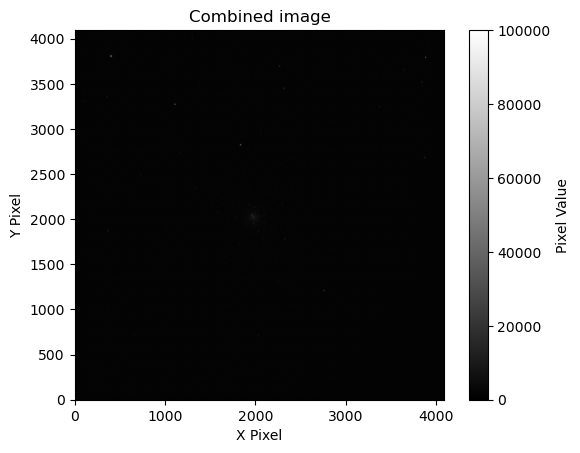

In [ ]:
### method to align the science frams for the small change in the camera

science_VBand = glob.glob('NGC_6341 Data/V-band/Reduced Science/*.fit')

#star 1
X1 = []
Y1 = []

#star 2
X2 = []
Y2 = []

#star 3
X3 = []
Y3 = []

reduced_Vband = []
frame = 0                                         #count to keep track of the frame its showing
for f in science_VBand:
    frame += 1
    fit =  astropy.nddata.CCDData.read(f, unit = 'adu')
    VbandFitarray = np.array(fit).astype(float)
    reduced_Vband.append(VbandFitarray)          ## appending reduced science frames to a list for combination later

    bkg = Background2D(VbandFitarray, (512, 512), filter_size=(5, 5), sigma_clip= SigmaClip(sigma=3.0), bkg_estimator=MedianBackground()) #calculating background - box size of 512x512 pixels, kernal size of 5x5 pixels, estimated using a median
    VbandFitarray2 = VbandFitarray - bkg.background
     
    threshold = 2.0 * bkg.background_rms_median # two root mean squared to confirm source
    kernel = make_2dgaussian_kernel(3.0, size=5) #creates gaussian with a fwhm of 3
    convolved_data = convolve(VbandFitarray2, kernel) #convolute the data and the gaussian
    sources = detect_sources(convolved_data, threshold, npixels=5)
    cat = SourceCatalog(VbandFitarray2, sources) #creating a source catalog using background subtracted data and deblened signals
    tbl = cat.to_table() #converting to table
    a = tbl['xcentroid']
    b = tbl['ycentroid']
    f = tbl['segment_flux']
    #print(frame)
    for m in range(0,len(a)):  #looping through the list
        if a[m]<450 and 3600<b[m]<4000 and f[m]>10000000:   #checking for sources
            X1.append(a[m])
            Y1.append(b[m])
            #print(a[m],b[m],f[m]) #print statment to ensure consistancy
            break
        else:
            continue
    for k in range(0,len(a)):  #looping through the list
        if 1000<a[k]<1200 and 3200<b[k]<3500 and f[k]>5000000:    #checking for sources
            X2.append(a[k])
            Y2.append(b[k])
            #print(a[k],b[k],f[k]) #print statment to ensure consistancy
            break
        else:
            continue
    for l in range(0,len(a)):  #looping through the list
        if 1800<a[l]<2000 and 2700<b[l]<3000 and f[l]>150000:    #checking for sources
            X3.append(a[l])
            Y3.append(b[l])
            #print(a[l],b[l],f[l])  #print statment to ensure consistancy
            break
        else:
            continue
            
ref_image = np.array([(X1[0],Y1[0]),(X2[0],Y2[0]),(X3[0],Y3[0])]) #target postions from the first science frames
aligned_V = []

for f in range(len(reduced_Vband)):
    test = np.array([(X1[f],Y1[f]),(X2[f],Y2[f]),(X3[f],Y3[f])]) ## stars position in each frame
    tform = astroalign.estimate_transform('affine',test, ref_image)  #finding matrix transformation
    m = astroalign.apply_transform(tform,reduced_Vband[f],reduced_Vband[0])  #applying transformation
    aligned_V.append(m[0])

summed_image_V = np.nanmedian(aligned_V, axis=0) ## median combining all the aligned frames

# creating the final image
plt.imshow(summed_image_V, origin ='lower', cmap = 'gist_gray',vmin = 0, vmax=10000)
plt.colorbar(label='Pixel Value')
plt.title("Combined image")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

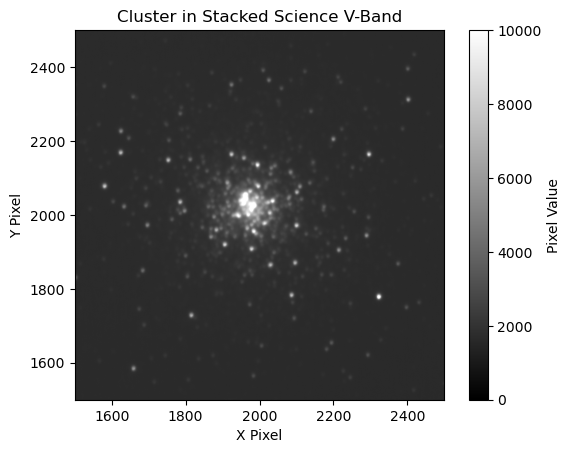

In [ ]:
plt.imshow(summed_image_V, origin ='lower', cmap = 'gist_gray',vmin = 0, vmax=10000) ### Zoomed in plot for the cluster to ensure that the image is not blurred/ has any errors
plt.colorbar(label='Pixel Value')
plt.title("Cluster in Stacked Science V-Band")
plt.xlim(1500,2500) # cluster position
plt.ylim(1500,2500)
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

### B-band ###

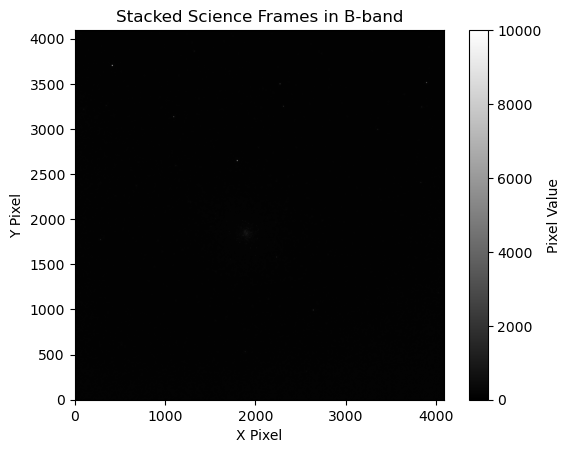

In [ ]:
science_BBand = glob.glob('NGC_6341 Data/B-band/Reduced Science/*.fit')

X1 = []
Y1 = []

#star 2
X2 = []
Y2 = []

#star 3
X3 = []
Y3 = []

reduced_Bband = []
frame = 0                         #count to keep track of the frame its showing
for f in science_BBand:
    frame += 1
    fit =  astropy.nddata.CCDData.read(f, unit = 'adu')
    BbandFitarray = np.array(fit).astype(float)
    reduced_Bband.append(BbandFitarray)    ## appending the reduced frame too combine later
    
    bkg = Background2D(BbandFitarray, (512, 512), filter_size=(5, 5), sigma_clip= SigmaClip(sigma=3.0), bkg_estimator=MedianBackground()) #calculating background- box size of 512x512 pixels, kernal size of 5x5 pixels, estimaued using a median
    BbandFitarray2 = BbandFitarray - bkg.background
    
    
    threshold = (2.0 * bkg.background_rms_median) #b two root means squared to confirm source
    kernel = make_2dgaussian_kernel(3.0, size=5) #creates gaussian with a fwhm of 3
    convolved_data = convolve(BbandFitarray2, kernel) #convolute the data and the gaussian
    sources = detect_sources(convolved_data, threshold, npixels=5)
    cat = SourceCatalog(BbandFitarray2, sources) #creating a source catalog using background subtracted data and deblened signals
    tbl = cat.to_table() #converting to table
    a = tbl['xcentroid']
    b = tbl['ycentroid']
    f = tbl['segment_flux']
    #print(frame)
    for m in range(0,len(a)):  #looping through the list
        if 300<a[m]<500 and 3600<b[m]<3800 and f[m]>10000:   #checking for sources
            X1.append(a[m])
            Y1.append(b[m])
            #print(a[m],b[m],f[m]) #print statment to ensure consistancy
            break
        else:
            continue
    for k in range(0,len(a)):  #looping through the list
        if 1000<a[k]<1500 and 3000<b[k]<3200 and f[k]>10000: #checking for sources
            X2.append(a[k])
            Y2.append(b[k])
            #print(a[k],b[k],f[k]) #print statment to ensure consistancy
            break
        else:
            continue
    for l in range(0,len(a)):  #looping through the list
        if 1600<a[l]<2000 and 2400<b[l]<2800 and f[l]>10000:    #checking for sources
            X3.append(a[l])
            Y3.append(b[l])
            #print(a[l],b[l],f[l])  #print statment to ensure consistancy
            break
        else:
            continue

ref_image = np.array([(X1[0],Y1[0]),(X2[0],Y2[0]),(X3[0],Y3[0])]) #target postions from the first science frames
aligned_B = []

for f in range(len(reduced_Bband)):
    test = np.array([(X1[f],Y1[f]),(X2[f],Y2[f]),(X3[f],Y3[f])])
    tform = astroalign.estimate_transform('affine',test, ref_image)  #finding matrix transformation
    m = astroalign.apply_transform(tform,reduced_Bband[f],reduced_Bband[0])  #applying transformation
    aligned_B.append(m[0])

summed_image_B = np.nanmedian(aligned_B, axis=0)  ## median combining the frames like previous calibration frames

# creating the final image
plt.imshow(summed_image_B, origin ='lower', cmap = 'gist_gray',vmin = 0, vmax=1000) 
plt.colorbar(label='Pixel Value')
plt.title("Stacked Science Frames in B-band")
#plt.xlim(1500,2500) # cluster position
#plt.ylim(1500,2500)
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

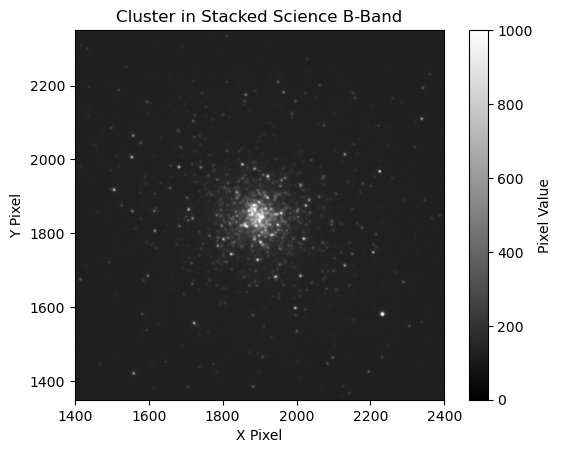

In [ ]:
plt.imshow(summed_image_B, origin ='lower', cmap = 'gist_gray',vmin = 0, vmax=1000) ### Zoomed in plot for the cluster to ensure that the image is not blurred/ has any errors
plt.colorbar(label='Pixel Value')
plt.title("Cluster in Stacked Science B-Band")
plt.xlim(1400,2400) # cluster position
plt.ylim(1350,2350)
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

## Source Extraction ##

### V-Band ###

In [ ]:
science_V = CCDData(summed_image_V, unit = 'adu')

hdul = astropy.nddata.CCDData.to_hdu(science_V)       ## creating the master frame 
hdul.writeto('NGC_6341 Data/V-band/Master Frames/MasterScienceFrame_V1.science.fit', overwrite = True)

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
1683.8131855228294 23.465851619795572


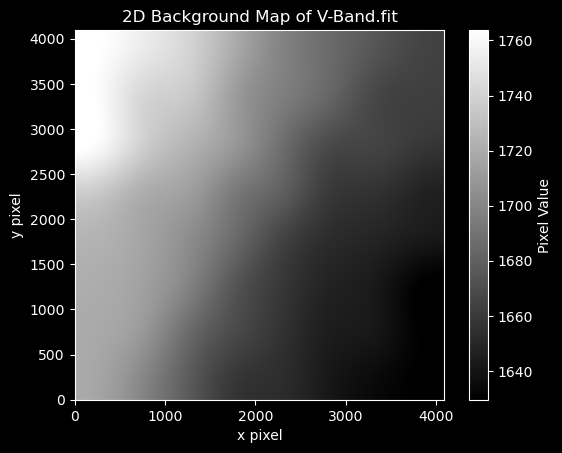

In [503]:
finalfitV = astropy.nddata.CCDData.read('NGC_6341 Data/V-band/Master Frames/MasterScienceFrame_V1.science.fit', unit ='adu')
finalfitVarray = np.array(finalfitV).astype(float)
bkg_V = Background2D(finalfitVarray, (512, 512), filter_size=(5, 5), sigma_clip = SigmaClip(sigma=3.0), bkg_estimator=MedianBackground()) #calculating background - box size of 512x512 pixels, kernal size of 5x5 pixels, estimated using a median

finalfitV_bkgsub = finalfitVarray - bkg_V.background ## subtracting the background from the data

plt.imshow(bkg_V.background, cmap = 'gist_gray', origin = 'lower')
plt.colorbar(label='Pixel Value')
plt.title('2D Background Map of V-Band.fit')
plt.xlabel('x pixel')

plt.ylabel('y pixel')
print(bkg_V.background_median, bkg_V.background_rms_median) ##printing the mean 

<photutils.segmentation.core.SegmentationImage>
shape: (4096, 4096)
nlabels: 1010
labels: [   1    2    3    4    5 ... 1006 1007 1008 1009 1010]


<photutils.segmentation.core.SegmentationImage>
shape: (4096, 4096)
nlabels: 1285
labels: [   1    2    3    4    5 ... 1281 1282 1283 1284 1285]


Text(0.5, 1.0, 'Deblended Segmentation Image V-Band')

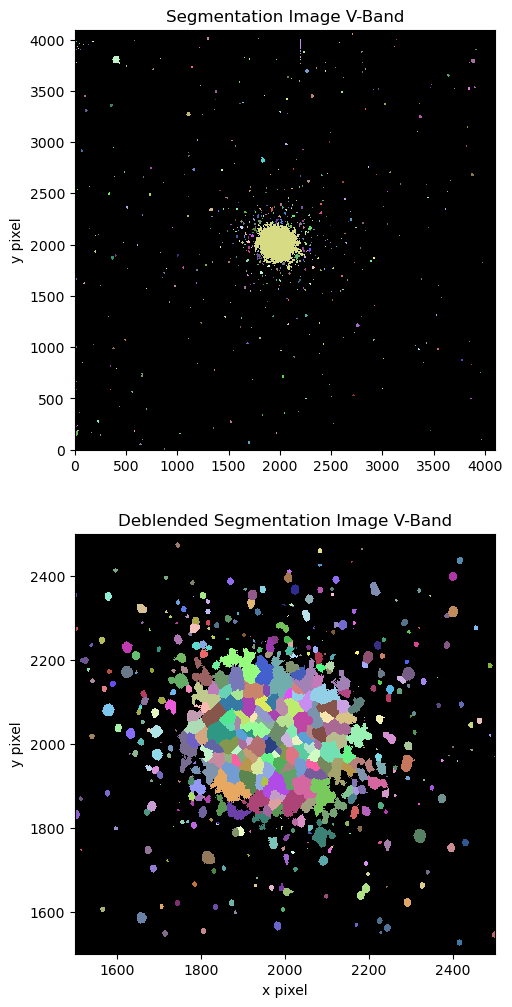

In [4]:
threshold =   ( 5 * bkg_V.background_rms_median)  ## setting the threshold for source detection to be 5 sigma as there's a lot of noise in the Vband
kernel = make_2dgaussian_kernel(3.0, size = 3)  ## creating a gaussian kernal with fwhm of 3 pixels and size of 3 pixels
convolved_data_V = convolve(finalfitV_bkgsub , kernel)

segment_map_V = detect_sources(convolved_data_V , threshold, npixels = 3 ) ## detecting the sources given the threshold, with atleast 3 pixels surrounding for fainter sources
print(segment_map_V)  ## number of sources picked up                                                

segm_deblend_V = deblend_sources(convolved_data_V, 
                               segment_map_V, npixels = 3 ,nlevels = 32, contrast = 0.001, progress_bar = False) ##deblending the segmentation to sepreate sources that are close together

print(segm_deblend_V)## number of deblended sources picked up

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12))

ax1.imshow(segment_map_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest') ## Sources on a black background
ax1.set_title('Segmentation Image V-Band')
ax1.set_ylabel('y pixel')  

ax2.imshow(segm_deblend_V,origin = 'lower', cmap=segment_map_V.cmap, interpolation='nearest') ## the core deblended
ax2.set_xlabel('x pixel')
ax2.set_ylabel('y pixel') 
ax2.set_xlim(1500,2500) # cluster position
ax2.set_ylim(1500,2500)
ax2.set_title('Deblended Segmentation Image V-Band')

In [5]:
effective_gain = 1.38         ## Gain from the header
error_V = calc_total_error(finalfitV_bkgsub, bkg_V.background_rms, effective_gain)    ## calculating the error for the flux

cat_V = SourceCatalog(finalfitV_bkgsub, segm_deblend_V, convolved_data = convolved_data_V, error = error_V) ## creating a table of the sources position and flux
labels = list(range(1, cat_V.nlabels + 1 ))       ## number of sources detected
cat_V_subset = cat_V.get_labels(labels)
tbl_V = cat_V_subset.to_table()
columns = ['label', 'xcentroid', 'ycentroid', 'eccentricity', 'segment_flux', 'segment_fluxerr', 'area' ]      ## printing the necessary columns
tbl_V = cat_V_subset.to_table(columns=columns)

print(tbl_V)


label     xcentroid          ycentroid      ...  segment_fluxerr    area
                                            ...                     pix2
----- ------------------ ------------------ ... ------------------ -----
    1  2142.483685048051 1.3164580757138433 ...  60.87670725857506   6.0
    2  871.7510858811951   8.91971367844316 ... 266.74300045947746  97.0
    3  709.3063823811003 17.509235286284934 ... 197.17101940116515  53.0
    4 3796.2101429081595  21.47262770376939 ...   78.0566387496464  10.0
    5 1.6680563216349191  44.32751089123717 ... 49.537443221326726   3.0
    6  638.8489139460354 55.840315083309285 ...  683.1287465596291 423.0
    7  21.83170310434571  50.99969515731087 ...  70.37980434343235   6.0
    8  1696.677860171886  71.97246217068542 ...  658.0356899020203 381.0
    9 15.393522610985556  64.18127869068516 ...  64.27190672245312   5.0
  ...                ...                ... ...                ...   ...
 1276 17.002789651544227  3985.277841266689 ...  75

### B-Band ###

In [17]:
science_B = CCDData(summed_image_B, unit = 'adu')

hdul = astropy.nddata.CCDData.to_hdu(science_B)       ## creating the master frame 
hdul.writeto('NGC_6341 Data/B-band/Master Frames/MasterScienceFrame_B.science.fit', overwrite = True)

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


Text(0.5, 0, 'X Pixel')

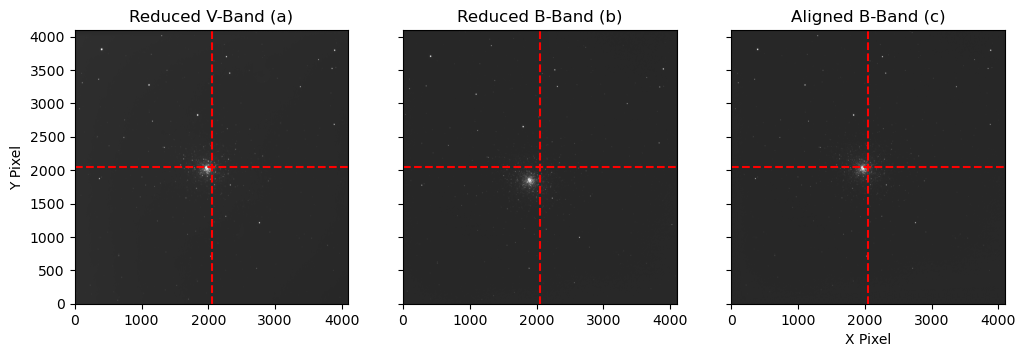

In [540]:
finalfitB = astropy.nddata.CCDData.read('NGC_6341 Data/B-band/Master Frames/MasterScienceFrame_B.science.fit', unit ='adu')
balignarray = np.array(finalfitB).astype(float)    

finalfitBarray, footprint = astroalign.register(balignarray, finalfitVarray)  ## aligning B-band to V-band to have the same approximate coordinates for stars 

plt.style.use('default')
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)                             ## Showing the V band as reference
plt.imshow(finalfitV,  origin='lower', cmap='gist_gray', vmin=0, vmax=10000)
plt.axhline(2048, color='red', linestyle='--')                    ## centre of frame as a good reference point
plt.axvline(2048, color='red', linestyle='--')
plt.title("Reduced V-Band (a)")    
plt.ylabel("Y Pixel")

plt.subplot(1, 3, 2)              ## Showing the B-band 
plt.imshow(finalfitB, origin='lower', cmap='gist_gray', vmin=0, vmax=800)
plt.axhline(2048, color='red', linestyle='--')                       ## centre of frame as a good reference point
plt.axvline(2048, color='red', linestyle='--')
plt.setp(plt.gca().get_yticklabels(), visible=False)
plt.title("Reduced B-Band (b)")    


plt.subplot(1, 3, 3)         ### Now showing the aligned B-band to the V-band coordinated
plt.imshow(finalfitBarray, origin='lower', cmap='gist_gray', vmin=0, vmax=800)
plt.axhline(2048, color='red', linestyle='--')
plt.axvline(2048, color='red', linestyle='--')                             ## centre of frame as a good reference point
plt.title("Aligned B-Band (c)")
plt.setp(plt.gca().get_yticklabels(), visible=False)
plt.xlabel("X Pixel")

#plt.savefig("NGC_6341 Images/Alignment of B to V Band.png")

125.12364532318952 2.771380297344022


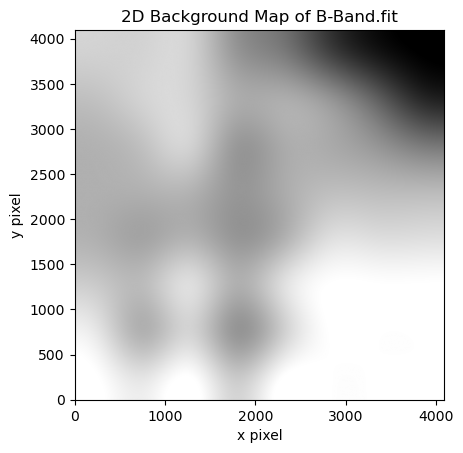

In [ ]:
bkg_B = Background2D(finalfitBarray, (512, 512), filter_size=(5, 5), sigma_clip = SigmaClip(sigma=3.0), bkg_estimator=MedianBackground())  #calculating background - box size of 512x512 pixels, kernal size of 5x5 pixels, estimated using a median

finalfitB_bkgsub = finalfitBarray - bkg_B.background  ## subtracting the background from the data

plt.imshow(bkg_B.background, cmap = 'gist_gray', origin = 'lower')
plt.title('2D Background Map of B-Band.fit')
plt.xlabel('x pixel')
plt.ylabel('y pixel')   
print(bkg_B.background_median, bkg_B.background_rms_median) ##printing the mean
#plt.savefig("NGC_6341 Images/2D background [B-band].png")

<photutils.segmentation.core.SegmentationImage>
shape: (4096, 4096)
nlabels: 1300
labels: [   1    2    3    4    5 ... 1296 1297 1298 1299 1300]


<photutils.segmentation.core.SegmentationImage>
shape: (4096, 4096)
nlabels: 1826
labels: [   1    2    3    4    5 ... 1822 1823 1824 1825 1826]


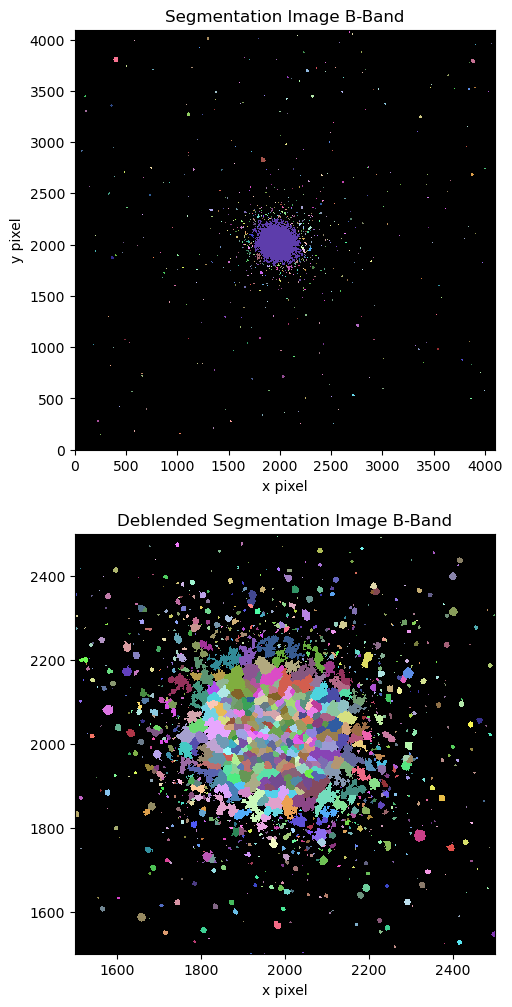

In [ ]:
threshold =   (3 * bkg_B.background_rms_median)  ## setting the threshold for source detection to be 3 sigma as there is not as much noise/background 
kernel = make_2dgaussian_kernel(3.0 , size = 3)  ## creating a gaussian kernal with fwhm of 3 pixels and size of 3 pixels
convolved_data_B = convolve(finalfitB_bkgsub, kernel)  ##convolving data

segment_map_B = detect_sources(convolved_data_B , threshold, npixels = 3 )  ## detecting the sources given the threshold, with atleast 3 pixels surrounding for fainter sources
print(segment_map_B)     ## number of sources picked up

segm_deblend_B = deblend_sources(convolved_data_B, 
                               segment_map_B, npixels = 3, nlevels = 32, contrast = 0.001, progress_bar = False) ##deblending the segmentation
 
print(segm_deblend_B) ## number of deblended sources picked up

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))     

ax1.imshow(segment_map_B, origin='lower', cmap=segment_map_B.cmap, interpolation='nearest')
ax1.set_title('Segmentation Image B-Band')
ax1.set_ylabel('y pixel')  
ax1.set_xlabel('x pixel')

ax2.imshow(segm_deblend_B,origin = 'lower', cmap=segment_map_B.cmap, interpolation='nearest')  ## the core deblended
ax2.set_xlabel('x pixel')
ax1.set_ylabel('y pixel') 
ax2.set_xlim(1500,2500) # cluster position
ax2.set_ylim(1500,2500)
ax2.set_title('Deblended Segmentation Image B-Band')

plt.savefig("NGC_6341 Images/Segmentation Image [B-band].png")

In [ ]:
error_B = calc_total_error(finalfitB_bkgsub, bkg_B.background_rms, 1.38)    ## calculating the error

cat_B = SourceCatalog(finalfitB_bkgsub, segm_deblend_B, convolved_data = convolved_data_B, error = error_B) ## creating a table of the sources position and flux
labels = list(range(1, cat_B.nlabels + 1 ))                ## number of sources detected
cat_B_subset = cat_B.get_labels(labels) 
tbl_B = cat_B_subset.to_table()
columns = ['label', 'xcentroid', 'ycentroid', 'eccentricity', 'segment_flux', 'segment_fluxerr', 'area' ]      ## printing the necessary columns
tbl_B = cat_B_subset.to_table(columns=columns)

print(tbl_B)

label     xcentroid          ycentroid      ...  segment_fluxerr    area 
                                            ...                     pix2 
----- ------------------ ------------------ ... ------------------ ------
    1  246.1808557906265 151.13164829631347 ...   53.2498081067213  142.0
    2 1024.4451912572395 161.78812456853453 ...  54.68081096265141  129.0
    3  579.1023733212432 183.35280866350683 ...   68.8080531559352  183.0
    4 1348.1589688673475  211.7684782632245 ...  90.75324223544618  228.0
    5   361.285991527727 225.36540771813262 ...  19.29512658125162   26.0
    6 1085.8831147056176 254.27086359891348 ... 15.530249948252612   16.0
    7  2339.634076882965  256.8454777077373 ... 21.633189893231748   29.0
    8 2516.2936830913222 258.83804674656795 ...  43.50811196339506   90.0
    9 2199.3236070277712  258.9084661920917 ... 22.293454414514127   31.0
  ...                ...                ... ...                ...    ...
 1817 2208.2479296123443  2359.4721233

### Combination ###

Text(0.5, 1.0, 'Deblended Segmentation Image B-Band')

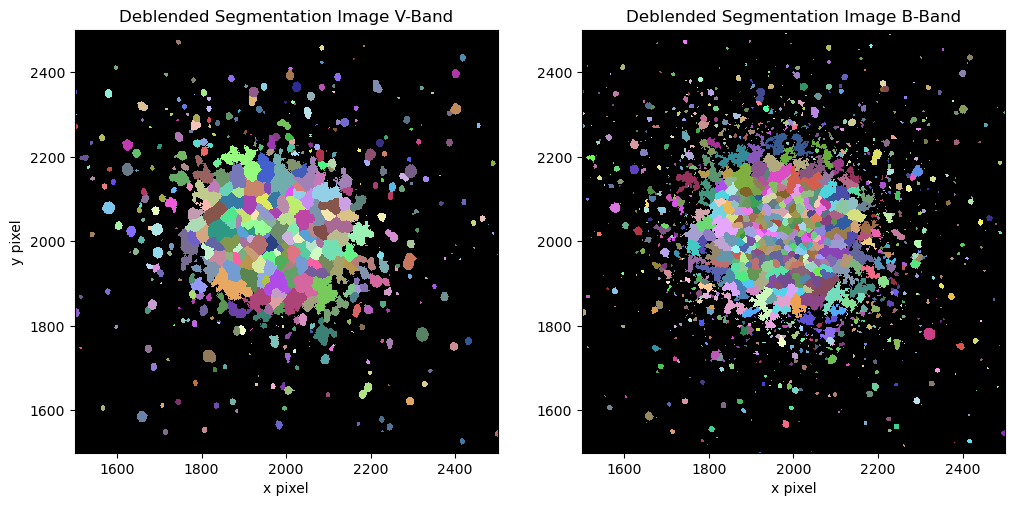

In [594]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))      ## Showing the deblended segmentation images for both bands side by side for comparison

ax1.imshow(segm_deblend_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest')
ax1.set_title('Deblended Segmentation Image V-Band')
ax1.set_ylabel('y pixel')  
ax1.set_xlabel('x pixel')
ax1.set_xlim(1500,2500) 
ax1.set_ylim(1500,2500)

ax2.imshow(segm_deblend_B,origin = 'lower', cmap=segment_map_B.cmap, interpolation='nearest')
ax2.set_xlabel('x pixel')
ax1.set_ylabel('y pixel') 
ax2.set_xlim(1500,2500) # cluster position
ax2.set_ylim(1500,2500)
ax2.set_title('Deblended Segmentation Image B-Band')

#plt.savefig("NGC_6341 Images/Segmentation Comparison B and V Band.png")

## We can see that the core is too dense and hard to identify the exact same sources, but the stars surrounding it are easier to match

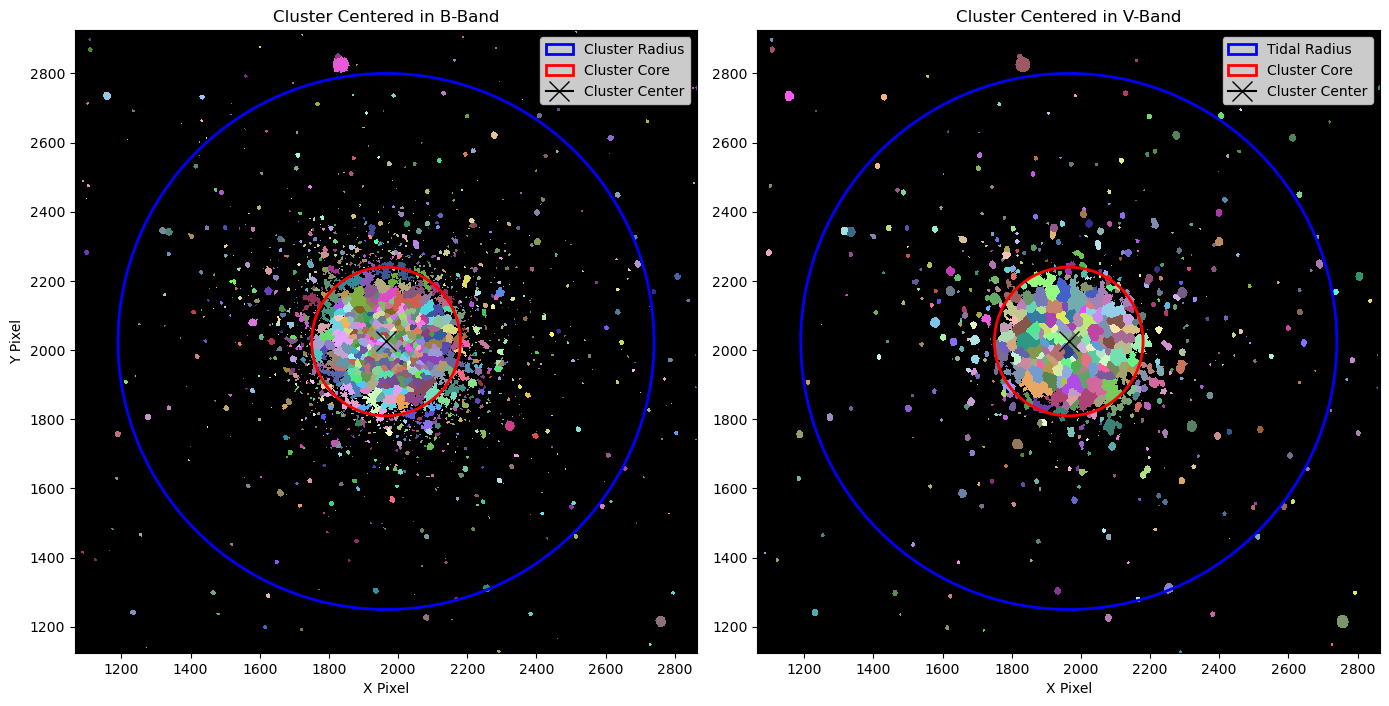

<Figure size 640x480 with 0 Axes>

In [595]:
center_x = 1965             ## the approximate centre of the cluster from sight
center_y = 2025


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(segm_deblend_B, origin='lower', cmap=segment_map_B.cmap, interpolation='nearest')

circle1_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')       ## Creating the annulus for the stars we're going to consider
circle1_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax1.add_patch(circle1_rad)
ax1.add_patch(circle1_core)

ax1.set_title("Cluster Centered in B-Band")
ax1.set_xlim(center_x - 900, center_x + 900)
ax1.set_ylim(center_y - 900, center_y + 900)
ax1.plot(center_x, center_y, marker='x', color='black', markersize=15, label='Cluster Center')
ax1.set_xlabel("X Pixel")
ax1.set_ylabel("Y Pixel")
ax1.legend()

ax2.imshow(segm_deblend_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest')

circle2_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')     ## Creating the annulus for the stars we're going to consider
circle2_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Tidal Radius')

ax2.add_patch(circle2_rad)
ax2.add_patch(circle2_core)

ax2.set_title("Cluster Centered in V-Band")
ax2.set_xlim(center_x - 900, center_x + 900)
ax2.set_ylim(center_y - 900, center_y + 900)
ax2.plot(center_x, center_y, marker='x', color='black', markersize=15, label='Cluster Center')
ax2.set_xlabel("X Pixel")
ax2.legend()

plt.tight_layout()
plt.show()
plt.savefig("NGC_6341 Images/Cluster Centered B and V Band.png")

In [596]:
v_points = np.column_stack((tbl_V['xcentroid'], tbl_V['ycentroid']))   ## stacking all the points in the tables
b_points = np.column_stack((tbl_B['xcentroid'], tbl_B['ycentroid']))


tree = cKDTree(b_points)    ## making a tree of all the points

dist, idx = tree.query(v_points, k=1)   ## making sure to only find 1 matching point for all atching sources
 
match_limit = 1.5     ## sources have to be within 1.5 pixels to be matched
is_match = dist < match_limit       

common_V = tbl_V[is_match]
common_B = tbl_B[idx[is_match]]    ##Making sure all the common star are found with the same index


print(f"Total V sources: {len(tbl_V)}")
print(f"Total B sources: {len(tbl_B)}")
print(f"Common stars found: {len(common_V)}")

cluster_center_x = 1965
cluster_center_y = 2025

core_radius = 215        ## making the annulus as previusly shown 
cluster_radius = 775 


distances = np.sqrt((common_V['xcentroid'] - cluster_center_x)**2 + 
                    (common_V['ycentroid'] - cluster_center_y)**2)


in_cluster = (distances < cluster_radius) & (distances > core_radius)    ## filtering the common sources to make sure its only within the annulus

final_cluster_V = common_V[in_cluster]
final_cluster_B = common_B[in_cluster] ##pulling them into a new list

print(f"Stars inside cluster region ({core_radius} < r < {cluster_radius}): {len(final_cluster_V)}")

Total V sources: 1285
Total B sources: 1826
Common stars found: 535
Stars inside cluster region (215 < r < 775): 287


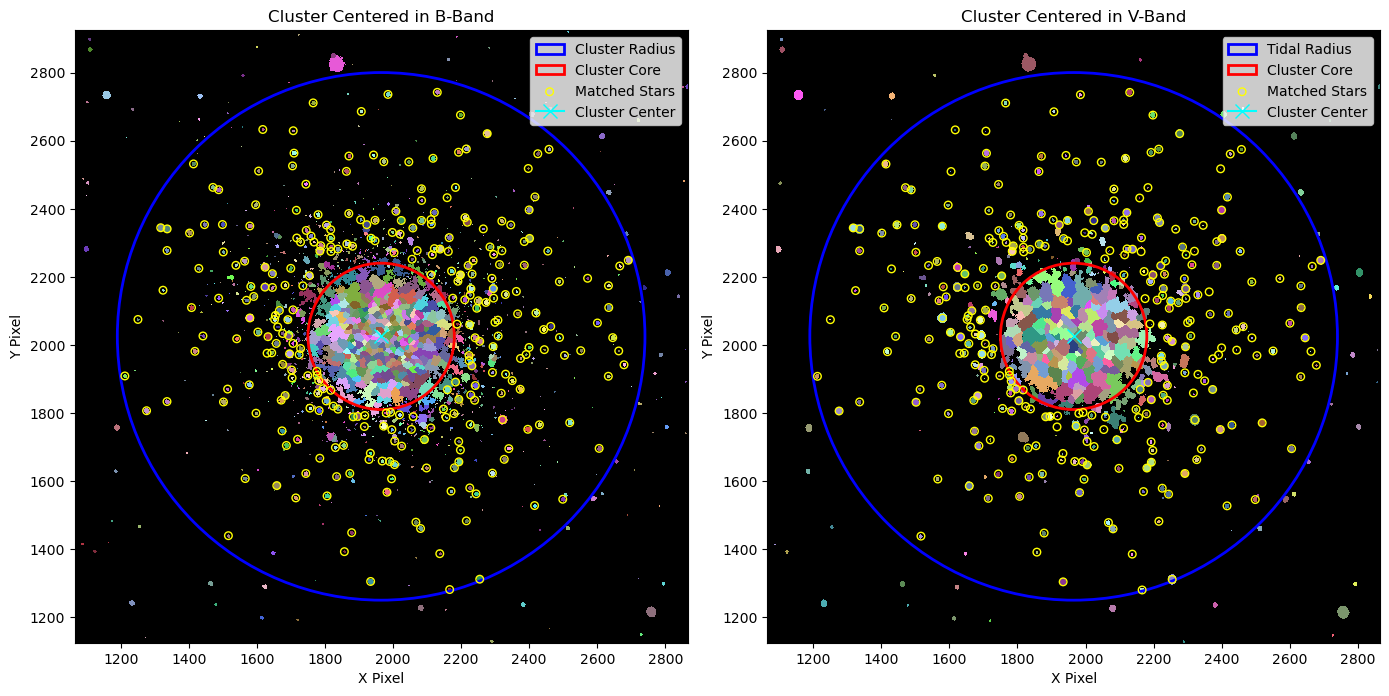

<Figure size 640x480 with 0 Axes>

In [597]:
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

### Plot to show all the identical stars in both bands

ax1.imshow(segm_deblend_B, origin='lower', cmap=segment_map_B.cmap, interpolation='nearest') 

circle1_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle1_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax1.add_patch(circle1_rad)
ax1.add_patch(circle1_core)

ax1.set_title("Cluster Centered in B-Band")
ax1.set_xlim(center_x - 900, center_x + 900)
ax1.set_ylim(center_y - 900, center_y + 900)
ax1.scatter(final_cluster_B['xcentroid'], final_cluster_B['ycentroid'], s=30, edgecolor='yellow', facecolor='none', label='Matched Stars')
ax1.plot(center_x, center_y, marker='x', color='cyan', markersize=10, label='Cluster Center')
ax1.set_xlabel("X Pixel")
ax1.set_ylabel("Y Pixel")
ax1.legend()

ax2.imshow(segm_deblend_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest')

circle2_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle2_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Tidal Radius')

ax2.add_patch(circle2_rad)
ax2.add_patch(circle2_core)

ax2.set_title("Cluster Centered in V-Band")
ax2.set_xlim(center_x - 900, center_x + 900)
ax2.set_ylim(center_y - 900, center_y + 900)
ax2.scatter(final_cluster_V['xcentroid'], final_cluster_V['ycentroid'], s=30, edgecolor='yellow', facecolor='none', label='Matched Stars')
ax2.plot(center_x, center_y, marker='x', color='cyan', markersize=10, label='Cluster Center')
ax2.set_xlabel("X Pixel")
ax2.set_ylabel("Y Pixel")
ax2.legend()

plt.tight_layout()
plt.show()
plt.savefig("NGC_6341 Images/Matched Stars in Cluster B and V Band.png")

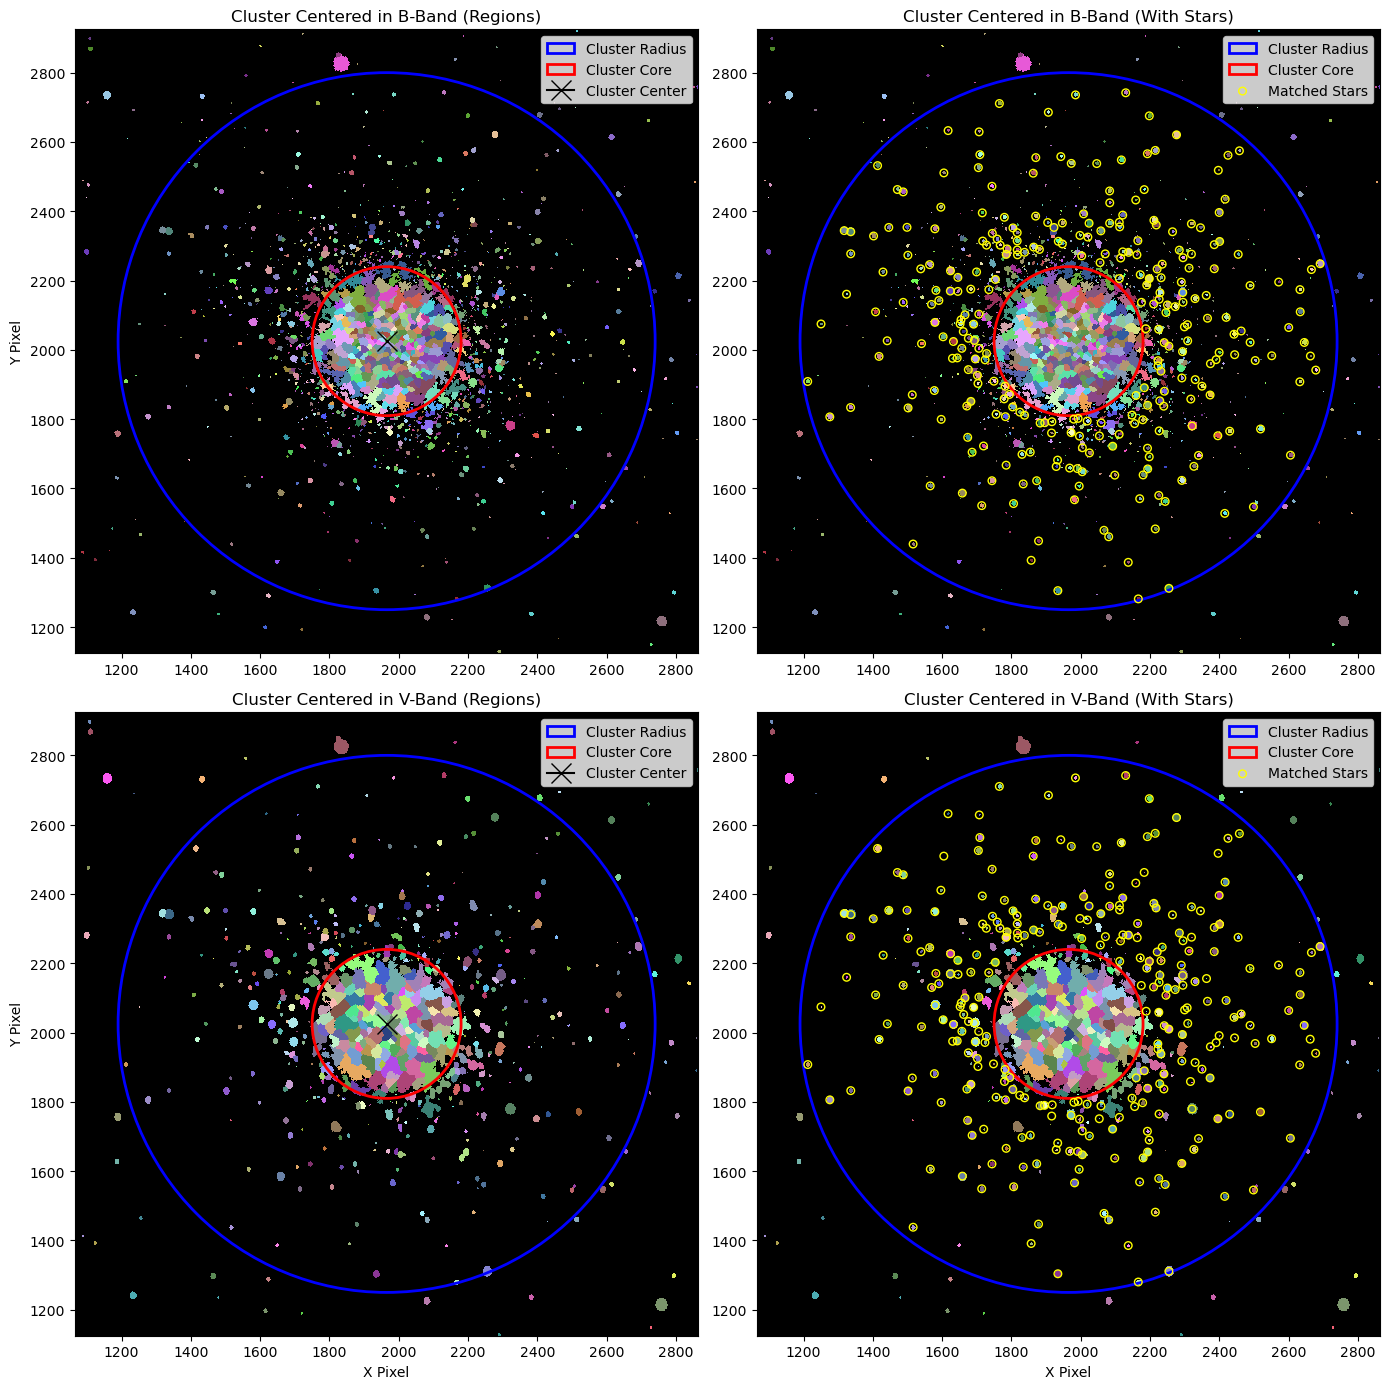

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.style.use('default')
center_x = 1965
center_y = 2025

## larger plot to put into Latex to compare the deblended images in both bands, as well the identical sources within the annulus

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Flatten the axes array for easier indexing if preferred, or index directly
# Structure: [[ax1, ax2], [ax3, ax4]]
ax1 = axes[0, 0] # Top-Left: B-Band (Regions only)
ax2 = axes[0, 1] # Top-Right: B-Band (With Stars)
ax3 = axes[1, 0] # Bottom-Left: V-Band (Regions only)
ax4 = axes[1, 1] # Bottom-Right: V-Band (With Stars)

# --- Top Left: B-Band Cluster Regions ---
ax1.imshow(segm_deblend_B, origin='lower', cmap=segment_map_B.cmap, interpolation='nearest')

circle1_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle1_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax1.add_patch(circle1_rad)
ax1.add_patch(circle1_core)

ax1.set_title("Cluster Centered in B-Band (Regions)")
ax1.set_xlim(center_x - 900, center_x + 900)
ax1.set_ylim(center_y - 900, center_y + 900)
ax1.plot(center_x, center_y, marker='x', color='black', markersize=15, label='Cluster Center')
ax1.set_ylabel("Y Pixel")
ax1.legend(loc='upper right')

# --- Top Right: B-Band with Matched Stars ---
ax2.imshow(segm_deblend_B, origin='lower', cmap=segment_map_B.cmap, interpolation='nearest')

circle2_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle2_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax2.add_patch(circle2_rad)
ax2.add_patch(circle2_core)

ax2.set_title("Cluster Centered in B-Band (With Stars)")
ax2.set_xlim(center_x - 900, center_x + 900)
ax2.set_ylim(center_y - 900, center_y + 900)
ax2.scatter(final_cluster_B['xcentroid'], final_cluster_B['ycentroid'], s=30, edgecolor='yellow', facecolor='none', label='Matched Stars')
ax2.legend(loc='upper right')

# --- Bottom Left: V-Band Cluster Regions ---
ax3.imshow(segm_deblend_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest')

circle3_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle3_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax3.add_patch(circle3_rad)
ax3.add_patch(circle3_core)

ax3.set_title("Cluster Centered in V-Band (Regions)")
ax3.set_xlim(center_x - 900, center_x + 900)
ax3.set_ylim(center_y - 900, center_y + 900)
ax3.plot(center_x, center_y, marker='x', color='black', markersize=15, label='Cluster Center')
ax3.set_xlabel("X Pixel")
ax3.set_ylabel("Y Pixel")
ax3.legend(loc='upper right')

# --- Bottom Right: V-Band with Matched Stars ---
ax4.imshow(segm_deblend_V, origin='lower', cmap=segment_map_V.cmap, interpolation='nearest')

circle4_core = plt.Circle((center_x, center_y), 215, color='red', fill=False, linewidth=2, label='Cluster Core')
circle4_rad = plt.Circle((center_x, center_y), 775, color='blue', fill=False, linewidth=2, label='Cluster Radius')

ax4.add_patch(circle4_rad)
ax4.add_patch(circle4_core)

ax4.set_title("Cluster Centered in V-Band (With Stars)")
ax4.set_xlim(center_x - 900, center_x + 900)
ax4.set_ylim(center_y - 900, center_y + 900)
ax4.scatter(final_cluster_V['xcentroid'], final_cluster_V['ycentroid'], s=30, edgecolor='yellow', facecolor='none', label='Matched Stars')
ax4.set_xlabel("X Pixel")
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

plt.savefig("NGC_6341 Images/Cluster Centered B and V Band Combined.png")

## Flux Calibration ##

### V-Band ###

In [ ]:
V_x = (tbl_V['xcentroid'] >= 390 ) & (tbl_V['xcentroid'] <= 410)  ### setting coordinated to find the chosen star
V_y = (tbl_V['ycentroid'] >= 3750) & (tbl_V['ycentroid'] <= 3850)

HD156964_V = tbl_V[V_x & V_y]
print(HD156964_V[0])  ## printing the properties of the star 

starx_V = HD156964_V[0][1]     ## saving the coordinates
stary_V = HD156964_V[0][2]
star_eccentricity_V = HD156964_V[0][3]

print(f'The coordinates of HD156964 in the V-Band is x: {starx_V}, y: {stary_V} with an eccentricity of {star_eccentricity_V}')

label     xcentroid          ycentroid        eccentricity       segment_flux    segment_fluxerr   area 
                                                                                                   pix2 
----- ------------------ ----------------- ------------------ ----------------- ----------------- ------
  732 398.54357751543995 3806.985997789713 0.3406626646708656 14135375.83936215 3754.016860006562 4193.0
The coordinates of HD156964 in the V-Band is x: 398.54357751543995, y: 3806.985997789713 with an eccentricity of 0.3406626646708656


 id      xcenter       ...  aperture_sum_39   aperture_sum_err_39
--- ------------------ ... ------------------ -------------------
  1 398.54357751543995 ... 14210047.872144137  3839.3774363008365


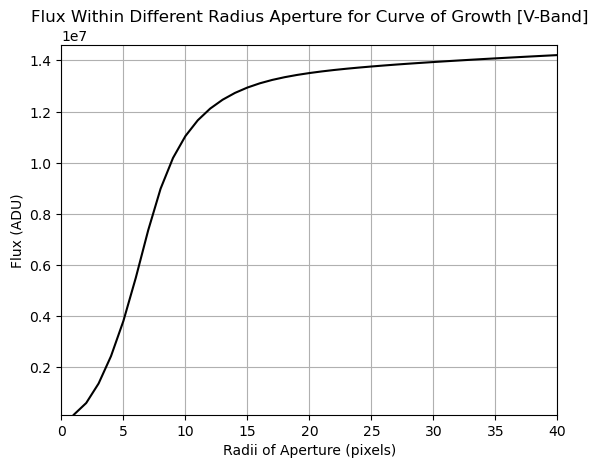

In [ ]:
position_V = (starx_V, stary_V)   ## Position of the star HD156964 in V-Band
radii = list(range(1,41))

apertures_V = [CircularAperture(position_V, r=i) for i in radii] ## conducting iterative aperture photometry 

phot_table_V = aperture_photometry(finalfitV_bkgsub, apertures_V, error = error_V)    ## Measuring the flux in different apetures
print(phot_table_V)
fluxes_V = phot_table_V[0][3::2]
fluxeserror_V = [0][4::2]

plt.plot(radii, fluxes_V , color = 'black')
plt.xlabel('Radii of Aperture (pixels)')           ## Plotting the Flux against Apeture size for Curve of Growth
plt.ylabel('Flux (ADU)')
plt.xlim(0,40)
plt.ylim(fluxes_V[0],1.46e7)
#plt.axvline(16)
plt.title('Flux Within Different Radius Aperture for Curve of Growth [V-Band]')  ## We can see from this that the graph does not flat line too umch background
plt.grid()
plt.savefig("NGC_6341 Images/Curve of Growth V-Band.png") 

Residual Background in 'subtracted' image: 84.8605 +/- 0.5159 ADU/pixel


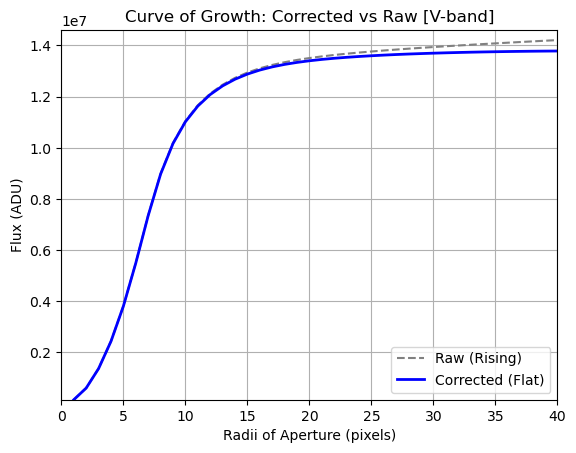

In [ ]:
sky_ref_annulus_V = CircularAnnulus(position_V, r_in=40, r_out=50)  ## making an annulus far away from the star
sky_stats_V = ApertureStats(finalfitV_bkgsub, sky_ref_annulus_V, error = error_V)
residual_bkg_per_pixel_V = sky_stats_V.median   ## setting the residual background to be the mean at this aperture
bkg_std = sky_stats_V.std
n_bkg_pixels = sky_ref_annulus_V.area    ## area of the annulus

bkg_mean_uncertainty = bkg_std / np.sqrt(n_bkg_pixels) ## error on the mean

print(f"Residual Background in 'subtracted' image: {residual_bkg_per_pixel_V:.4f} +/- {bkg_mean_uncertainty:.4f} ADU/pixel")

corrected_fluxes_V = []
corrected_fluxes_V_err = []
raw_fluxes_V = []

for r in radii:
    ap = CircularAperture(position_V, r=r)
    
    # Measure flux
    table = aperture_photometry(finalfitV_bkgsub, ap, error = error_V)
    raw_flux = table['aperture_sum'][0]
    raw_flux_err = table['aperture_sum_err'][0]
    
    correction = residual_bkg_per_pixel_V * ap.area            ### calculating the background in the area of the aperture 
    final_flux = raw_flux - correction                           ### subtracting the background
    
    corrected_fluxes_V.append(final_flux)
    raw_fluxes_V.append(raw_flux)

    variance_total = (raw_flux_err**2) + (ap.area * bkg_mean_uncertainty)**2      ##finding the error on the flux
    total_err = np.sqrt(variance_total)
    
    corrected_fluxes_V_err.append(total_err)


plt.plot(radii, raw_fluxes_V, color='gray', linestyle='--', label='Raw (Rising)')   ##original data
plt.plot(radii, corrected_fluxes_V, color='blue', linewidth=2, label='Corrected (Flat)')      ##showing th eplot for corrceted flux
plt.xlabel('Radii of Aperture (pixels)')
plt.ylabel('Flux (ADU)')
plt.xlim(0,40)
plt.ylim(corrected_fluxes_V[0],1.46e7)
#plt.axvline(16, color='red', label='Selected Radius (16)')
plt.title('Curve of Growth: Corrected vs Raw [V-band]')
plt.legend()
plt.grid(True)

#plt.savefig("NGC_6341 Images/Curve of Growth Corrected vs Raw V-Band.png")
## A much more accurate plot

From the multiple annulus we can deduce that the mean background with radius R_in = 15 R_out = 16 is 1715.5495441187745 and with radius R_in = 16 R_out = 17 is 1275.3033994326274 and from previous background estimation it is 1683.8131855228294 therefore we can choose a radius of 16 pixels 


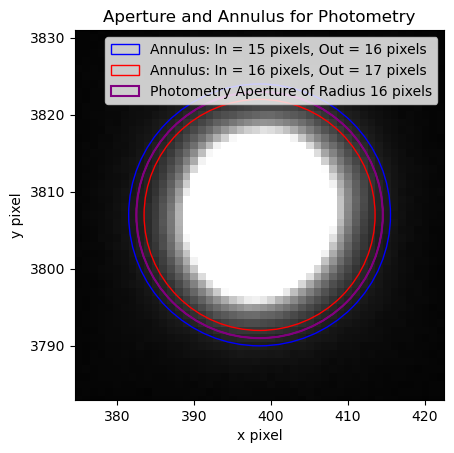

In [ ]:
test = 16  ## changing the radius

aperture_V = CircularAperture(position_V, r = test)  
annulus_aperture_V = CircularAnnulus(position_V, r_in = test - 1 , r_out = test)   ## Doing annulus photometry
annulus_aperture2_V = CircularAnnulus(position_V, r_in = test, r_out = test + 1)

plt.imshow(finalfitV_bkgsub, cmap = 'gist_gray',  vmin = 0 , vmax = 10000)
plt.xlim(starx_V - test*1.5 ,starx_V + test*1.5)                ## Setting limits to zoom into the star +/- 1.5*radius
plt.ylim(stary_V - test*1.5 ,stary_V + test*1.5)
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.title('Aperture and Annulus for Photometry')

annulus_patches_V = annulus_aperture2_V.plot(color='blue', lw=1,
                           label= f'Annulus: In = {test -1} pixels, Out = {test} pixels')
annulus_patches2_V = annulus_aperture_V.plot(color='red', lw=1,
                           label= f'Annulus: In = {test} pixels, Out = {test + 1} pixels')
ap_patches_V = aperture_V.plot(color='purple', lw=1.5,
                           label= f'Photometry Aperture of Radius {test} pixels') 
plt.legend()

aperstats_V = ApertureStats(finalfitV_bkgsub, annulus_aperture_V)        
aperstats2_V = ApertureStats(finalfitV_bkgsub, annulus_aperture2_V)
bkg_mean_V = aperstats_V.mean ## mean pixel value from smaller annulus 
bkg2_mean_V = aperstats2_V.mean ## mean pixel value from larger annulus 
print(f'From the multiple annulus we can deduce that the mean background with radius R_in = {test -1} R_out = {test } is {bkg_mean_V} and with radius R_in = {test } R_out = {test + 1} is {bkg2_mean_V} and from previous background estimation it is {bkg_V.background_median} therefore we can choose a radius of {test} pixels ') 
 ## Comparing the mean pixel values against the background from before to see when the flux should be considered


plt.savefig("NGC_6341 Images/Aperture and Annulus [V-Band].png")

In [ ]:
ScienceFrames_V = glob.glob('NGC_6341 Data/V-band/Science_V/*.fit')

airmass_v_list = []

for i in ScienceFrames_V:
    science = astropy.nddata.CCDData.read(i, unit = 'adu')
    airmass_v = science.header['AIRMASS']                       ### Finding the airmass from the header of the frame
    airmass_v_list.append(airmass_v)

print(np.mean(airmass_v_list))      ## the mean of the airmass since we took the mean of the frames
starflux_V = corrected_fluxes_V[test - 1]
starflux_error = corrected_fluxes_V_err[test - 1]          ## finding the flux for the radius earier (r =16)

imag_V = - 2.5 * np.log10(starflux_V)        ## Calculating the instrumental magnitude for aperture of radius 16 pixels
imag2error_V = - (2.5 / np.log(10)) * starflux_error / starflux_V

amag_V = 8.655                ## Given apparent magnitude +- error of HD156964 in V-band
amag_V_error = 0.0025       ## Given error in apparent magnitude of HD156964 in V-band
zp_V = amag_V - imag_V - 0.1 * np.mean(airmass_v_list)     ## Calculating the zero point
zp_error_V = np.sqrt(imag2error_V**2 + amag_V_error**2)  ## zero point error

print(f'The total instrumental magnitude is {imag_V} wihh an error of {imag2error_V} ')
print(np.mean(airmass_v_list))
print(f'The zero point in V band is {zp_V} with an error of {zp_error_V} ')

Set OBSGEO-Y to  -131185.767 from OBSGEO-[LBH].
Set OBSGEO-Z to  5055549.706 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


1.5886972341654444
The total instrumental magnitude is -17.78810056784272 wihh an error of -0.00027693751163373055 
1.5886972341654444
The zero point in V band is 26.284230844426176 with an error of 0.0025152921073604718 


### B-Band ###

In [ ]:
B_x = (tbl_B['xcentroid'] >= 390 ) & (tbl_B['xcentroid'] <= 410)  ## Position of the star HD156964 in B-Band
B_y = (tbl_B['ycentroid'] >= 3750) & (tbl_B['ycentroid'] <= 4000)

HD156964_B = tbl_B[B_x & B_y] ## printing the properties of the star
starx_B = HD156964_B[0][1] ## saving the coordinates
stary_B = HD156964_B[0][2]
star_eccentricity_B = HD156964_B[0][3]

print(f'The coordinates of HD156964 in the B-Band is x: {starx_B}, y: {stary_B} with an eccentricity of {star_eccentricity_B}')
print(HD156964_B)

The coordinates of HD156964 in the B-Band is x: 398.18009563726457, y: 3806.393582250922 with an eccentricity of 0.3074793237247177
label     xcentroid          ycentroid     ...  segment_fluxerr   area 
                                           ...                    pix2 
----- ------------------ ----------------- ... ----------------- ------
 1133 398.18009563726457 3806.393582250922 ... 989.3091508358715 1998.0


 id      xcenter       ...  aperture_sum_38    aperture_sum_39  
--- ------------------ ... ------------------ ------------------
  1 398.18009563726457 ... 1232569.3601808846 1232998.9517114833


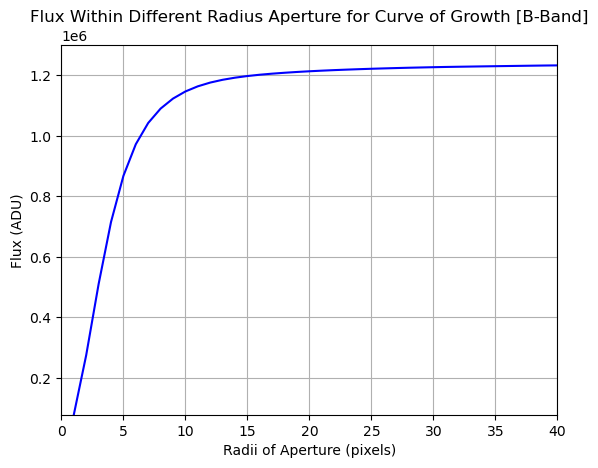

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.style.use('default')

position_B = (starx_B, stary_B)   ## Position of the star HD156964 in B-Band
radii = list(range(1,41))

apertures_B = [CircularAperture(position_B, r=i) for i in radii] ## conducting iterative aperture photometry 

phot_table_B = aperture_photometry(finalfitB_bkgsub, apertures_B)    ## Measuring the flux in different apetures
print(phot_table_B)
fluxes_B = phot_table_B[0][3::1]

plt.plot(radii, fluxes_B , color = 'blue')
plt.xlabel('Radii of Aperture (pixels)')           ## Plotting the Flux against Radius  
plt.ylabel('Flux (ADU)')
plt.xlim(0,40)
plt.ylim(fluxes_B[0],1.3e6)   
#plt.axvline(12, color = 'red')
plt.title('Flux Within Different Radius Aperture for Curve of Growth [B-Band]') ## the flux does flatlie as there is not too much background
plt.grid()
plt.show()
plt.savefig("NGC_6341 Images/Curve of Growth B-Band.png")

Residual Background in 'subtracted' image: 1.0812 ADU/pixel


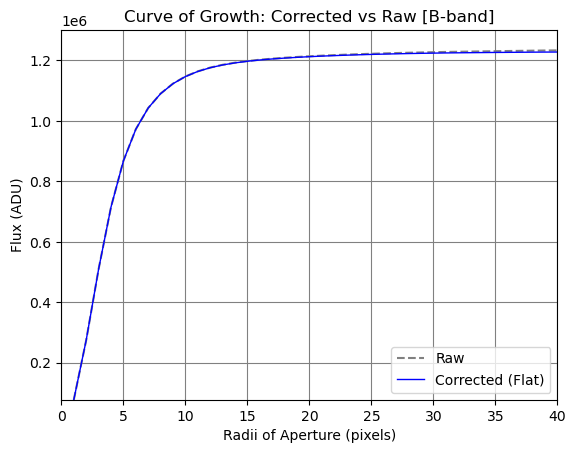

<Figure size 640x480 with 0 Axes>

In [ ]:
sky_ref_annulus_B = CircularAnnulus(position_B, r_in=40, r_out=50) ## making an annulus far away from the star
sky_stats_B = ApertureStats(finalfitB_bkgsub, sky_ref_annulus_B, error = error_B)
residual_bkg_per_pixel_B = sky_stats_B.median ## setting the residual background to be the mean at this aperture
bkg_std_B = sky_stats_B.std
n_bkg_pixels_B = sky_ref_annulus_B.area   ## area of the annulus

bkg_mean_uncertainty_B = bkg_std_B / np.sqrt(n_bkg_pixels_B) ## error on the mean

print(f"Residual Background in 'subtracted' image: {residual_bkg_per_pixel_B:.4f} +/- {bkg_mean_uncertainty:.4f} ADU/pixel")

corrected_fluxes_B = []
corrected_fluxes_B_err = []
raw_fluxes_B = []

for r in radii:
    ap = CircularAperture(position_B, r=r)
    
    # Measure flux
    table = aperture_photometry(finalfitB_bkgsub, ap, error = error_B)
    raw_flux = table['aperture_sum'][0]
    raw_flux_err = table['aperture_sum_err'][0]
    
    correction = residual_bkg_per_pixel_B * ap.area  ### calculating the background in the area of the aperture 
    final_flux = raw_flux - correction  ## subtracting the background
     
    corrected_fluxes_B.append(final_flux)
    raw_fluxes_B.append(raw_flux)

    variance_total = (raw_flux_err**2) + (ap.area * bkg_mean_uncertainty_B)**2   ##finding the error on the flux
    total_err = np.sqrt(variance_total)
    
    corrected_fluxes_B_err.append(total_err)


plt.plot(radii, raw_fluxes_B, color='gray', linestyle='--', label='Raw')  ##original data
plt.plot(radii, corrected_fluxes_B, color='blue', linewidth=1, label='Corrected (Flat)')  ##showing th eplot for corrceted flux
plt.xlabel('Radii of Aperture (pixels)')
plt.ylabel('Flux (ADU)')
plt.xlim(0,40)
plt.ylim(corrected_fluxes_B[0],1.3e6)
#plt.axvline(12, color='red', label='Selected Radius (12)')
plt.title('Curve of Growth: Corrected vs Raw [B-band]')
plt.legend()
plt.grid(True, color = 'gray')
plt.show()
plt.savefig("NGC_6341 Images/Curve of Growth Corrected vs Raw B-Band.png")  ## the backgound is very small that it barely makes a difference

From the multiple annulus we can deduce that the mean pixel value with radius R_in = 11 R_out = 12 is 170.88822950141562 and with radius R_in = 12 R_out = 13 is 115.65111902564993 and from previous background estimation it is 125.12364532318952 therefore we can choose a radius of 12 pixels 


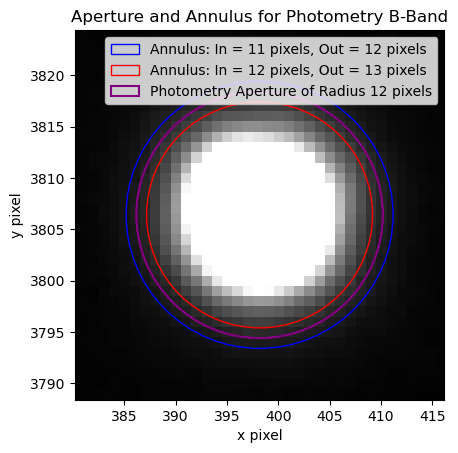

<Figure size 640x480 with 0 Axes>

In [ ]:
test = 12  ## changing the radius

aperture_B = CircularAperture(position_B, r = test)
annulus_aperture_B = CircularAnnulus(position_B, r_in = test - 1 , r_out = test)  ## Doing annulus photometry
annulus_aperture2_B = CircularAnnulus(position_B, r_in = test, r_out = test + 1)

plt.imshow(finalfitB_bkgsub, cmap = 'gist_gray',  vmin = 0 , vmax = 1000)
plt.xlim(starx_B - test*1.5 ,starx_B + test*1.5)
plt.ylim(stary_B - test*1.5 ,stary_B + test*1.5)         ## Setting limits to zoom into the star +/- 1.5*radius
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.title('Aperture and Annulus for Photometry B-Band')

annulus_patches_B = annulus_aperture2_B.plot(color='blue', lw=1,
                           label= f'Annulus: In = {test -1} pixels, Out = {test} pixels')
annulus_patches2_B = annulus_aperture_B.plot(color='red', lw=1,
                           label= f'Annulus: In = {test} pixels, Out = {test + 1} pixels')
ap_patches_B = aperture_B.plot(color='purple', lw=1.5,  
                           label= f'Photometry Aperture of Radius {test} pixels')   
plt.legend()

aperstats_B = ApertureStats(finalfitB_bkgsub, annulus_aperture_B)
aperstats2_B = ApertureStats(finalfitB_bkgsub, annulus_aperture2_B)
bkg_mean_B = aperstats_B.mean ## mean pixel value from smaller annulus 
bkg2_mean_B = aperstats2_B.mean## mean pixel value from larger annulus 
print(f'From the multiple annulus we can deduce that the mean pixel value with radius R_in = {test -1} R_out = {test } is {bkg_mean_B} and with radius R_in = {test } R_out = {test + 1} is {bkg2_mean_B} and from previous background estimation it is {bkg_B.background_median} therefore we can choose a radius of {test} pixels ') 
 ## Calculating the mean background from the annulus for when it is less than the background estimated previously
plt.show()
plt.savefig("NGC_6341 Images/Aperture and Annulus [B-Band].png")

In [ ]:
ScienceFrames_B = glob.glob('NGC_6341 Data/B-band/Science_B/*.fit')
airmass_b_list = []
for i in ScienceFrames_B:
    science = astropy.nddata.CCDData.read(i, unit = 'adu')
    airmass_b = science.header['AIRMASS']         ### Finding the airmass from the header of the frame
    airmass_b_list.append(airmass_b)


 
starflux_B = fluxes_B[test - 1]
starflux_error_B = corrected_fluxes_B_err[test - 1] ## finding the flux for the radius earier (r =12)

imag_B = - 2.5 * np.log10(starflux_B)        ## Calculating the instrumental magnitude for aperture of radius 12 pixels
imag2error_B = - (2.5 / np.log(10)) * starflux_error_B / starflux_B


amag_B = 9.745                ## Given apparent magnitude of HD156964 in B-band
amag_B_error = 0.0025          ## Given error in apparent magnitude of HD156964 in B-band

zp_B = amag_B - imag_B - 0.2 * np.mean(airmass_b_list)   ## Calculating the zero point
zp_error_B = np.sqrt(imag2error_B**2 + amag_B_error**2)

print(np.mean(airmass_b_list)) ## the mean of the airmass since we took the mean of the frames
print(f'The total instrumental magnitude is {imag_B} with an error of {imag2error_B} ')
print(f'The zero point in B band is {zp_B} with an error of {zp_error_B} ')

Set OBSGEO-Y to  -131185.767 from OBSGEO-[LBH].
Set OBSGEO-Z to  5055549.706 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


1.3547323531168693
The total instrumental magnitude is -15.176145400102023 with an error of -0.0008904396585347138 
The zero point in B band is 24.650198929478645 with an error of 0.0026538430220138147 


## CMD Plots ##

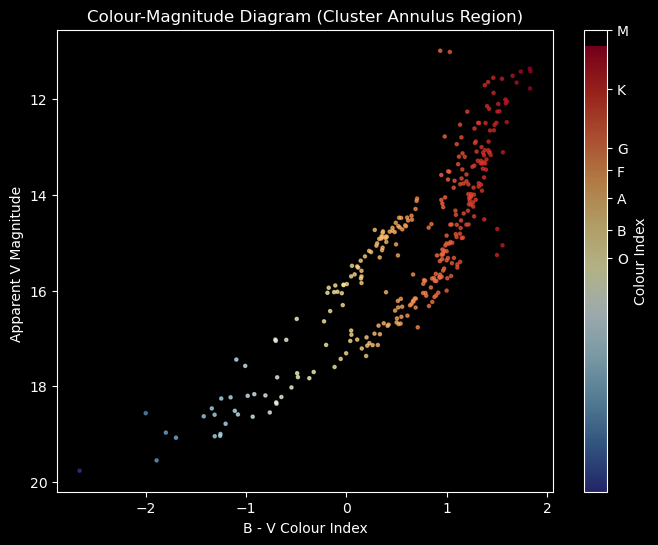

In [ ]:
plt.style.use('dark_background')

amags_V_old = - 2.5 * np.log10(final_cluster_V['segment_flux']) + zp_V   ## calculating the magnitudes of the b and V segment fluxes for common sources

amags_B_old = - 2.5 * np.log10(final_cluster_B['segment_flux']) + zp_B

color_BV_old =  amags_B_old - amags_V_old  ## calcualting the colour index


plt.figure(figsize=(8,6))

scatter1 = plt.scatter(color_BV_old , amags_V_old, s=5, alpha=0.7, c = color_BV_old, cmap='RdYlBu_r')  ## plotting this with a colour map to show the type of star
#plt.errorbar( color_BV , amags_V, yerr= final_table_V['app_mags_V_err'], xerr = colour_BV_err , fmt='none', ecolor='white', alpha=0.5, capsize=1)
#plt.gca().invert_yaxis() # Magnitudes go backwards!
plt.xlabel('B - V Colour Index')
plt.ylabel('Apparent V Magnitude ')
plt.title('Colour-Magnitude Diagram (Cluster Annulus Region)')


## just to make the colour index match the spectral types
cbar = plt.colorbar(scatter1, label='Colour Index',orientation = 'vertical',)
ticks = [-0.3,-0.02,0.3,0.58,0.81,1.40,2.0]
tick_labels = ['O','B','A','F','G','K','M']
plt.gca().invert_yaxis()
cbar.ax.set_xlim(0, 1)
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)

plt.show()
#plt.savefig("NGC_6341 Images/Color-Magnitude Diagram Old Calibration.png")

In [ ]:
results_V = []

FIXED_RADIUS = 4.5            ## making a fixed radius for photometry of all stars in the annulus 
ANNULUS_IN = 2*FIXED_RADIUS
ANNULUS_OUT = 3*FIXED_RADIUS

for f in final_cluster_V:
    positions_V = (f['xcentroid'], f['ycentroid'])  ## position of stars


    aper_V = CircularAperture(positions_V, r=FIXED_RADIUS)            ## aperture at the radius
    ann_V = CircularAnnulus(positions_V, r_in=ANNULUS_IN, r_out=ANNULUS_OUT)  ## annulus at far away

    phot_table_V2 = aperture_photometry(finalfitV_bkgsub, aper_V, error=error_V)  ## aperture photometry 
    phot_table_V2['aperture_area'] = aper_V.area

    phot_table_V2['id'] = f['label']

    sky_stats_V2 = ApertureStats(finalfitV_bkgsub, ann_V)     ## finding an the residual background close to the star
    residual_bkg_per_pixel_V2 = sky_stats_V2.median   

   
    flux_correction_V2 = residual_bkg_per_pixel_V2 * aper_V.area
    corrected_flux_V2 = phot_table_V2['aperture_sum'][0] - flux_correction_V2  ##correcting for the backround
    corrected_fluxerr_V2 = phot_table_V2['aperture_sum_err'][0]

    
    phot_table_V2['corrected_flux_V2'] = corrected_flux_V2
    phot_table_V2['corrected_fluxerr_V2'] = corrected_fluxerr_V2

   
    if corrected_flux_V2 > 0:        ## making sure the flux isn't less than zero for incorrect logs (probably from faint sources or backgroud)
        inst_mags_V = -2.5 * np.log10(corrected_flux_V2)
        inst_mags_V_err = (2.5/np.log(10)) * (corrected_fluxerr_V2 / corrected_flux_V2)
    else:
        inst_mags_V = np.nan
        inst_mags_V_err = np.nan           

    phot_table_V2['inst_mags_V'] = inst_mags_V
    phot_table_V2['inst_mags_V_err'] = inst_mags_V_err

    
    app_mags_V = inst_mags_V + zp_V  ## converting the corrected fluxes to apparent magnitude
    app_mags_V_err = np.sqrt((inst_mags_V_err**2) + (zp_error_V**2))

    phot_table_V2['app_mags_V'] = app_mags_V
    phot_table_V2['app_mags_V_err'] = app_mags_V_err

    results_V.append(phot_table_V2)

final_table_V = vstack(results_V)

In [ ]:
results_B = []

# Fixed settings for ALL stars
FIXED_RADIUS = 4.5  ## 1.5 x FWHM
ANNULUS_IN = 2*FIXED_RADIUS
ANNULUS_OUT = 3*FIXED_RADIUS

for f in final_cluster_B:
    positions_B = (f['xcentroid'], f['ycentroid']) ## position of stars

    aper_B = CircularAperture(positions_B, r=FIXED_RADIUS) ## aperture at the radius
    ann_B = CircularAnnulus(positions_B, r_in=ANNULUS_IN, r_out=ANNULUS_OUT)  ## annulus at far away
    
    

    phot_table_B2 = aperture_photometry(finalfitB_bkgsub, aper_B, error=error_B)
    phot_table_B2['aperture_area'] = aper_B.area

    phot_table_B2['id'] = f['label']

    sky_stats_B2 = ApertureStats(finalfitB_bkgsub, ann_B) ## finding an the residual background close to the star
    residual_bkg_per_pixel_B2 = sky_stats_B2.median

    
    flux_correction_B2 = residual_bkg_per_pixel_B2 * aper_B.area   ##correcting for the backround
    corrected_flux_B2 = phot_table_B2['aperture_sum'][0] - flux_correction_B2
    corrected_fluxerr_B2 = phot_table_B2['aperture_sum_err'][0]

    phot_table_B2['corrected_flux_B2'] = corrected_flux_B2
    phot_table_B2['corrected_fluxerr_B2'] = corrected_fluxerr_B2


    if corrected_flux_B2 > 0:  ## making sure the flux isn't less than zero for incorrect logs (probably from faint sources or backgroud)
        inst_mags_B = -2.5 * np.log10(corrected_flux_B2)
        inst_mags_B_err = (2.5/np.log(10)) * (corrected_fluxerr_B2 / corrected_flux_B2)
    else:
        inst_mags_B = np.nan
        inst_mags_B_err = np.nan

    phot_table_B2['inst_mags_B'] = inst_mags_B
    phot_table_B2['inst_mags_B_err'] = inst_mags_B_err

 
    app_mags_B = inst_mags_B + zp_B  ## converting the corrected fluxes to apparent magnitude
    app_mags_B_err = np.sqrt((inst_mags_B_err**2) + (zp_error_B**2))

    phot_table_B2['app_mags_B'] = app_mags_B
    phot_table_B2['app_mags_B_err'] = app_mags_B_err

    results_B.append(phot_table_B2)

final_table_B = vstack(results_B)

In [ ]:
amags_V = final_table_V['app_mags_V'] 

amags_B = final_table_B['app_mags_B']

color_BV =  amags_B - amags_V    ## calulating the colour index
colour_BV_err = np.sqrt(final_table_B['app_mags_B_err']**2 + final_table_V['app_mags_V_err']**2)

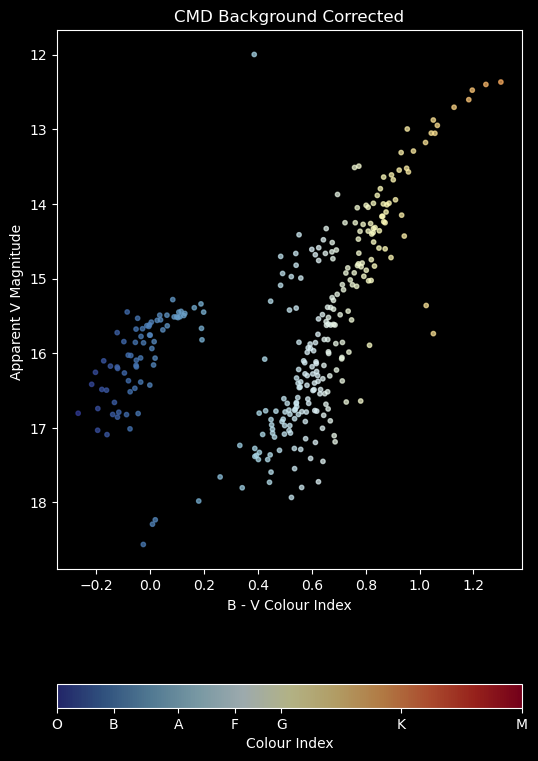

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,10))
## plotting the now corrected data
scatter = plt.scatter(color_BV , amags_V, s=10, alpha=0.7, c = color_BV, cmap='RdYlBu_r', vmin = -0.3 , vmax = 2.0)

plt.xlabel('B - V Colour Index')
plt.ylabel('Apparent V Magnitude ')
plt.title('CMD Background Corrected')
plt.gca().invert_yaxis()
## same colour system
cbar = plt.colorbar(label='Colour Index',orientation = 'horizontal',)
ticks = [-0.3,-0.02,0.3,0.58,0.81,1.40, 2.0]
tick_labels = ['O','B','A','F','G','K', 'M']
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)

plt.show()
plt.savefig("NGC_6341 Images/Color-Magnitude Diagram Background Corrected.png")

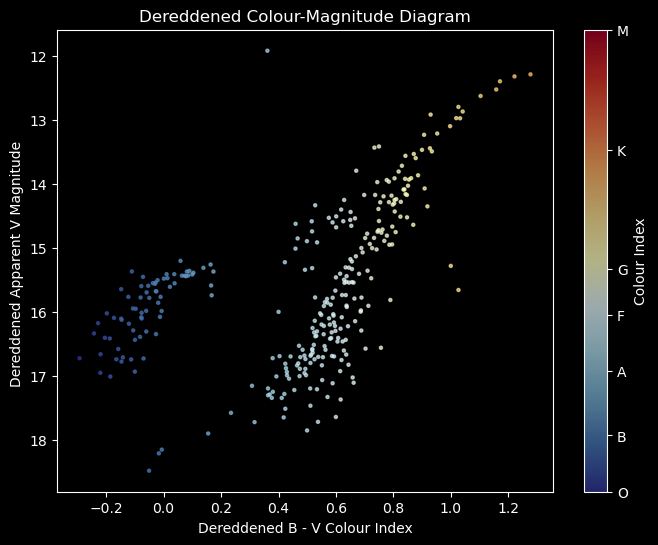

In [ ]:
E_BV = 0.025  ## colour excess
E_BV_error = 0.010  ## colour excess error

R_V = 3.1  ## Reddening coeffienct for V band data

A_V = R_V * E_BV  ## total extinction  to V ratio 
A_V_error = R_V * E_BV_error

CI_dereddened = color_BV - E_BV  ## correcting the Colour index error
CI_dereddened_error = np.sqrt(colour_BV_err**2 + E_BV_error**2)

m_V_dereddened = amags_V - A_V ## correcting the apparent magnitudes for reddening
m_V_dereddened_error = np.sqrt(colour_BV_err**2 + A_V_error**2)

plt.figure(figsize=(8,6))
scatter3 = plt.scatter(CI_dereddened , m_V_dereddened, s=5, alpha=0.7, c = CI_dereddened, cmap='RdYlBu_r', vmin = -0.3 , vmax = 2.0)
plt.xlabel('Dereddened B - V Colour Index')
plt.ylabel('Dereddened Apparent V Magnitude ')
plt.title('Dereddened Colour-Magnitude Diagram')
plt.gca().invert_yaxis()
cbar = plt.colorbar(label='Colour Index',orientation = 'vertical',)
ticks = [-0.3,-0.02,0.3,0.58,0.81,1.40, 2.0]
tick_labels = ['O','B','A','F','G','K', 'M']
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)

plt.savefig("NGC_6341 Images/Dereddened Color-Magnitude Diagram.png")


C:\Users\sahil\AppData\Local\Temp\ipykernel_7424\3758865772.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  iso_1 = pd.read_csv(f, delim_whitespace=True, comment='#')
C:\Users\sahil\AppData\Local\Temp\ipykernel_7424\3758865772.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  iso_1 = pd.read_csv(f, delim_whitespace=True, comment='#')
C:\Users\sahil\AppData\Local\Temp\ipykernel_7424\3758865772.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  iso_1 = pd.read_csv(f, delim_whitespace=True, comment='#')
C:\Users\sahil\AppData\Local\Temp\ipykernel_7424\3758865772.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``s

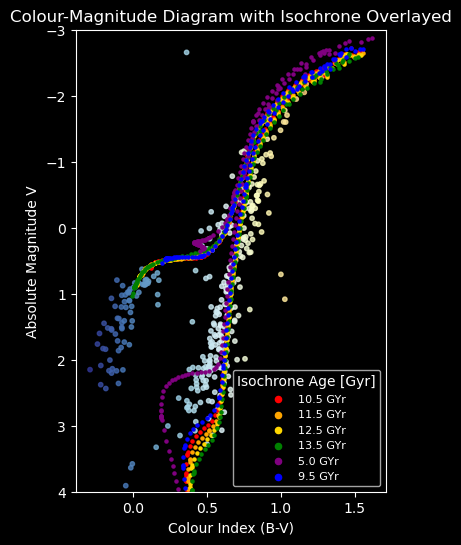

In [600]:
plt.style.use('dark_background')

files = glob.glob("NGC_6341 Data/Isochrones/*.dat")  ## Finding the isochrone data 
import os
colours = ['red','orange','gold','green','purple', 'blue']

d = 8231  ## sitance to the cluster
derr = 347

distancemoderr = (5/np.log(10)) * (derr/d)  ## calculating the distance modulus
distancemod = 5*np.log10(d) -5 

absmag_V = m_V_dereddened - distancemod ## converting the apparent magnituds to the absolute
absmag_V_err = np.sqrt(m_V_dereddened_error**2 + distancemoderr**2)
plt.figure(figsize=(4,6))
plt.scatter(CI_dereddened, absmag_V, s=10, alpha=0.8, c=CI_dereddened, cmap='RdYlBu_r', vmin=-0.3, vmax=2.0)  #plottng the CMD for absolute magnitude
#plt.errorbar(CI_dereddened,absmag_V, yerr = CI_dereddened_error, xerr=absmag_V_err, fmt = 'none' )   ## error bars for the data
for f,c in zip(files,colours): ## pulling out the relevelent data from the isochrone files
    iso_1 = pd.read_csv(f, delim_whitespace=True, comment='#')

    iso = iso_1.iloc[:, -9:]
    iso.columns = ["mbolmag","Umag","Bmag","Vmag","Rmag","Imag","Jmag","Hmag","Kmag"]

    iso = iso[(iso["Bmag"] < 20) & (iso["Vmag"] < 20)]

    B_dered = iso["Bmag"]
    V_dered = iso["Vmag"]

    iso_color = iso["Bmag"] - iso["Vmag"]
    iso_mag   = iso["Vmag"]

    fname = os.path.basename(f).replace(".dat","")
    age_label = fname.split("_")[-1]

    plt.scatter(iso_color.values, iso_mag.values, s=5, color =c, label=age_label) ## plotting a diffrent colour for each age in the files



plt.gca().invert_yaxis()
plt.xlabel("Colour Index (B-V)")
plt.ylabel("Absolute Magnitude V")
plt.title("Colour-Magnitude Diagram with Isochrone Overlayed")
#plt.xlim(0,2)
plt.ylim(4,-3)
plt.legend(title = "Isochrone Age [Gyr]", markerscale=2, fontsize=8)
#plt.savefig("Isochrone Overlayed CMD")
plt.show()

## Sensitivity Calculation ##

C:\Users\sahil\AppData\Local\Temp\ipykernel_7424\3420966615.py:19: RuntimeWarning: invalid value encountered in log10
  instmag_sensV = - 2.5 * np.log10(sorted_flux_V)                       ## Converting to instrumental magnitude


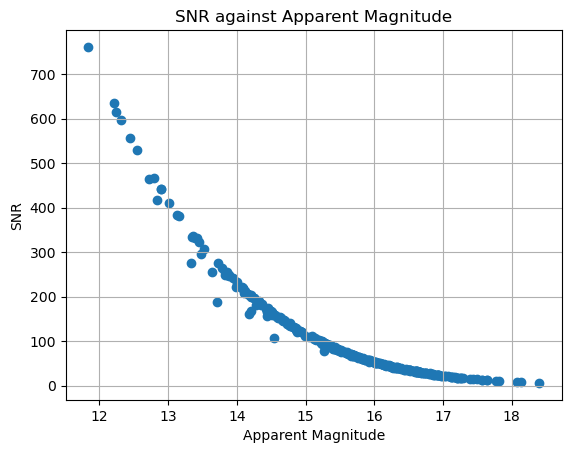

In [ ]:
plt.style.use('default')

#fluxerrors_sens_V = tbl_V['segment_fluxerr']
#flux_sens = tbl_V['segment_flux']

fluxerrors_sens_V = final_table_V['corrected_fluxerr_V2']  ## getting the segmetn fluxes as this is the raw flux from the instrument
flux_sens = final_table_V['corrected_flux_V2']


fluxes_array_sens = np.array(flux_sens)
fluxeserr_array_sens = np.array(fluxerrors_sens_V)

sort_ind = np.argsort(fluxes_array_sens)                        ## Just organising the fluxes in order
sorted_flux_V = fluxes_array_sens[sort_ind] 
sorted_fluxerr_V = fluxeserr_array_sens[sort_ind]

snr_V = sorted_flux_V / sorted_fluxerr_V

instmag_sensV = - 2.5 * np.log10(sorted_flux_V)                       ## Converting to instrumental magnitude
instmagerr_sensV =  -2.5 * sorted_fluxerr_V / sorted_flux_V / np.log(10)

appmag_sensV = instmag_sensV + zp_V - 0.1 * np.mean(airmass_v_list)        ## Converting to apparent magnitude with airmass correction
appmagerr_sensV = np.sqrt(instmagerr_sensV**2 + zp_error_V**2)                 ## Converting to apparent


plt.scatter(appmag_sensV, snr_V) ## plotting the SNR against apparent magnitude
plt.ylabel('SNR')
plt.xlabel('Apparent Magnitude')
plt.title('SNR against Apparent Magnitude')
plt.grid()

In [ ]:
def exp_decay(x, a, b, c):  ## general exoponential decay
    return a * np.exp(- b * x) + c


popt, pcov = curve_fit(exp_decay, appmag_sensV, snr_V)   ## finding best fit parameters for the deacy given the data

intercept = - (np.log((5 - popt[2]) /  popt[0])) / popt[1]

x_fit = np.linspace(min(appmag_sensV), max(appmag_sensV) , 100000)
y_fit = exp_decay(x_fit, *popt)

intercept = - (np.log((5 - popt[2]) /  popt[0])) / popt[1]  ## finding the intercept of when SNR = 5
print(intercept)

plt.scatter(appmag_sensV, snr_V, label = 'Data' )
plt.plot(x_fit, y_fit, color = 'orange', label = 'Fitted Curve')

plt.axvline(intercept, color = 'red', linestyle = '--', label = f'5 SNR Intercept at {intercept:.2f} mag')
plt.axhline(5, color = 'red', linestyle = '--')

plt.title('SNR against Apparent Magnitude with Fitted Curve')
plt.ylabel('SNR')
plt.xlabel('Apparent Magnitude')
plt.grid()
plt.legend()